# Libraries

In [ ]:
from rl_opts.rl_framework.numba.agents import Foragers, Forager, Foragers_efficient

from rl_opts.rl_framework.numba.environments import CollectiveEnv, TargetEnv, TargetEnv_timedelay, plot_multi_agents_in_cone

from numba import njit, prange
import numba

import os

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Load the autoreload extension
%load_ext autoreload

# Automatically reload all modules before executing code
%autoreload 2

# EXP 1

> Debugging

In [ ]:
agents = Foragers(num_agents=2, num_actions=2, size_state_space=np.array([3,3]), gamma_damping=0.1, eta_glow_damping=0.1) 

observation = np.array([[0,2],[1,2.0]])

percepts = agents.percept_preprocess(observation) 

probs = agents.probability_distr(percepts)

agents.deliberate(observation)
print('gmatrix: \n', agents.g_matrix)

agents.learn(np.random.rand(agents.num_agents))
print('hmatrix: \n', agents.h_matrix.round(2))

print('agent states before action: \n', agents.agent_states)
agents.act(np.array([0,1]))
print('agent states after action: \n', agents.agent_states)

gmatrix: 
 [[[0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 1. 0. 0.]]

 [[0. 0. 0. 0. 0. 0. 0. 1. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0.]]]
hmatrix: 
 [[[1.   1.   1.   1.   1.   1.   1.   1.   1.  ]
  [1.   1.   1.   1.   1.   1.   1.61 1.   1.  ]]

 [[1.   1.   1.   1.   1.   1.   1.   1.32 1.  ]
  [1.   1.   1.   1.   1.   1.   1.   1.   1.  ]]]
agent states before action: 
 [0 0]
agent states after action: 
 [1 0]


In [ ]:
env = CollectiveEnv(num_agents = 20, L = 50, shared_depletion = False)

episodes = 10000

env.init_env()

rews = np.zeros((episodes, env.num_agents))
agents_spotted = np.zeros((episodes, env.num_agents))

for ep in range(episodes):
    
   action = np.bool(np.random.randint(0, 2, size=env.num_agents)) # Random actions for all agents

   env.update_pos(action)
   env.update_target_state()
   
   rews[ep] = env.check_encounter()
   agents_spotted[ep] = env.agents_in_cone()

   env.check_bc()


## Test: rewarded when turning at specific counter

In [ ]:
rewarded_counter = 5

num_agents = 5

max_counter = 100
size_state_space = np.array([max_counter, num_agents])

agents = Foragers(num_agents = num_agents, num_actions = 2, size_state_space = size_state_space, gamma_damping = 0.001, eta_glow_damping = 0) 
env = CollectiveEnv(num_agents = num_agents, L = 5, shared_depletion = True)


episodes = 1000
time_ep = 50
save_rewards = np.zeros((num_agents,episodes))
    
for ep in range(episodes):
    
    # initialize environment and agent's counter and g matrix
    env.init_env()
    agents.agent_states = np.zeros(num_agents, dtype=np.int64)                                   
    agents.reset_g()

    for t in range(time_ep):

        # Update the target state
        # env.update_target_state()

        counters = agents.get_state()
        agents_spotted = env.agents_in_cone()
        observations = np.vstack((counters, agents_spotted)).T.astype(np.float64)

       

        actions = agents.deliberate(observations)
        agents.act(actions)

        # We consider that the action of changing direction is taken when action == 1, and action == 0 means keep the same direction.        
        env.update_pos(actions.astype(bool))

        # Instead of typical reward:
        # rewards = env.check_encounter()
        # We reward if agent counter is above threshold:
        mask_reward = agents.agent_states > rewarded_counter        
        rewards = (mask_reward).astype(int)

        agents.agent_states[mask_reward] = 0
        save_rewards[:, ep] += rewards

        agents.learn(rewards)



        


Exception ignored on calling ctypes callback function: <function ExecutionEngine._raw_object_cache_notify>
Traceback (most recent call last):
  File "/home/gorka/miniconda3/envs/rl_opts_origin/lib/python3.11/site-packages/llvmlite/binding/executionengine.py", line 178, in _raw_object_cache_notify
    def _raw_object_cache_notify(self, data):

KeyboardInterrupt: 


<matplotlib.lines.Line2D>

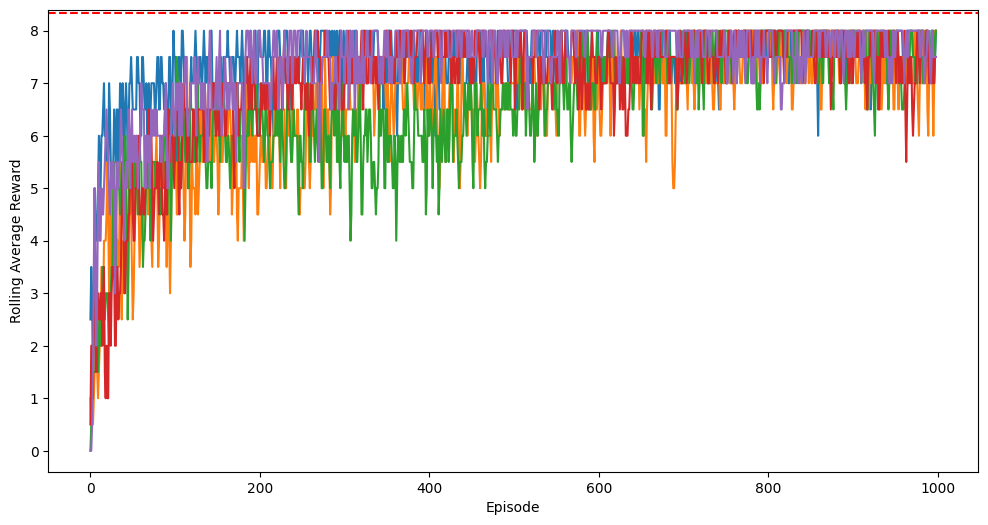

In [ ]:
# plot rolling average for the reward of each agent
window_size = 2
rolling_avg_rewards = np.zeros_like(save_rewards)[:, :-(window_size-1)]
for i in range(save_rewards.shape[0]):
    rolling_avg_rewards[i] = np.convolve(save_rewards[i], np.ones(window_size)/window_size, mode='valid')
plt.figure(figsize=(12, 6))
for i in range(save_rewards.shape[0]):
    plt.plot(rolling_avg_rewards[i], label=f'Agent {i+1}')
plt.xlabel('Episode')
plt.ylabel('Rolling Average Reward')
plt.axhline(time_ep/(rewarded_counter+1), color='r', linestyle='--', label='Reward Threshold')    

## Test: normal exploration, no visual cue

In [ ]:
from numba import njit
from tqdm.auto import tqdm

In [ ]:
@njit
def training_test_2(episodes, time_ep, env, agents): 

    save_rewards = np.zeros((agents.num_agents,episodes))

    agents_spotted = np.zeros_like(env.agents_in_cone())

    for ep in range(episodes):
        
        # initialize environment and agent's counter and g matrix
        env.init_env()
        
        agents.agent_states = np.zeros_like(agents.agent_states)
        agents.reset_g()

        for t in range(time_ep):

            # Update the target state
            env.update_target_state()

            # Only counters as inputs
            counters = agents.get_state()
            # agents_spotted = np.zeros_like(env.agents_in_cone())
            observations = np.vstack((counters, agents_spotted)).T.astype(np.float64)

            actions = agents.deliberate(observations)        
            
            # Update agent's states and env positions
            agents.act(actions)     
            env.update_pos(actions == 1)
            env.check_bc()

            # # Instead of typical reward:
            rewards = env.check_encounter()        
            save_rewards[:, ep] += rewards
            agents.learn(rewards)

    return save_rewards, agents

### Optimization

In [ ]:
try:
    import optuna
except ImportError:
    %pip install optuna
    import optuna

def objective(trial):
    gamma_damping = trial.suggest_float("gamma_damping", 1e-4, 5e-1, log=True)
    eta_glow_damping = trial.suggest_float("eta_glow_damping", 1e-4, 5e-1, log=True)

    num_agents_local = 20
    max_counter_local = 100
    size_state_space_local = np.array([max_counter_local, num_agents_local])

    agents_local = Foragers(
        num_agents=num_agents_local,
        num_actions=2,
        size_state_space=size_state_space_local,
        gamma_damping=gamma_damping,
        eta_glow_damping=eta_glow_damping,
    )
    env_local = CollectiveEnv(
        num_agents=num_agents_local,
        L=100,
        r=0.5,
        Nt=100, tau = 3,
        shared_depletion=True,
    )

    # training_test_2 uses the global num_agents variable internally
    global num_agents
    num_agents = num_agents_local

    episodes_opt = 200
    time_ep_opt = 500
    save_rewards, _ = training_test_2(episodes_opt, time_ep_opt, env_local, agents_local)

    return float(save_rewards[:,-5:].mean())

study = optuna.create_study(direction="maximize", study_name="training_test_2_tuning", load_if_exists=True)
study.optimize(objective, n_trials=30)

print("Best value:", study.best_value)
print("Best params:", study.best_params)
study.best_trial

[I 2026-03-30 17:36:37,912] A new study created in memory with name: training_test_2_tuning


[I 2026-03-30 17:37:02,696] Trial 0 finished with value: 3.73 and parameters: {'gamma_damping': 0.0007805748359141132, 'eta_glow_damping': 0.1632736097872833}. Best is trial 0 with value: 3.73.
[I 2026-03-30 17:37:27,448] Trial 1 finished with value: 3.59 and parameters: {'gamma_damping': 0.15155456119886945, 'eta_glow_damping': 0.010172012250489582}. Best is trial 0 with value: 3.73.
[I 2026-03-30 17:37:52,164] Trial 2 finished with value: 3.42 and parameters: {'gamma_damping': 0.06692046199909406, 'eta_glow_damping': 0.14366128744489665}. Best is trial 0 with value: 3.73.
[I 2026-03-30 17:38:16,907] Trial 3 finished with value: 3.53 and parameters: {'gamma_damping': 0.23231882926514222, 'eta_glow_damping': 0.00017604917866407982}. Best is trial 0 with value: 3.73.
[I 2026-03-30 17:38:41,620] Trial 4 finished with value: 3.91 and parameters: {'gamma_damping': 0.24293431447254354, 'eta_glow_damping': 0.2195413482494156}. Best is trial 4 with value: 3.91.
[I 2026-03-30 17:39:06,345] Tri

Best value: 4.12
Best params: {'gamma_damping': 0.424525373612266, 'eta_glow_damping': 0.00011806222923204531}


FrozenTrial(number=5, state=<TrialState.COMPLETE: 1>, values=[4.12], datetime_start=datetime.datetime(2026, 3, 30, 17, 38, 41, 620550), datetime_complete=datetime.datetime(2026, 3, 30, 17, 39, 6, 345111), params={'gamma_damping': 0.424525373612266, 'eta_glow_damping': 0.00011806222923204531}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'gamma_damping': FloatDistribution(high=0.5, log=True, low=0.0001, step=None), 'eta_glow_damping': FloatDistribution(high=0.5, log=True, low=0.0001, step=None)}, trial_id=5, value=None)

In [ ]:
num_agents = 20

max_counter = 50

# We don't consider now visual cue
size_state_space = np.array([max_counter, num_agents])

params = {'gamma_damping': 0.00011337196820475596, 'eta_glow_damping': 0.10018353839606674}
agents = Foragers(num_agents = num_agents, num_actions = 2, size_state_space = size_state_space, 
                  gamma_damping = params['gamma_damping'], eta_glow_damping = params['eta_glow_damping']) 

env = CollectiveEnv(num_agents = num_agents, L = 100, r = 0.5, Nt = 100, shared_depletion = True, tau = 10)


episodes = 1000
time_ep = 500

save_rewards, agents = training_test_2(episodes, time_ep, env, agents)

In [ ]:
probs = agents.h_matrix[:,0,:100] / agents.h_matrix[:,:,:100].sum(1)

[<matplotlib.lines.Line2D>]

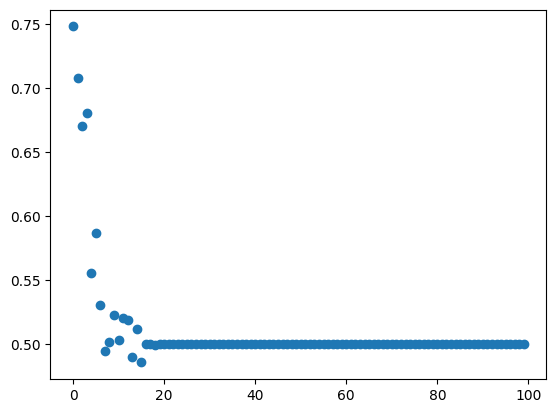

In [ ]:
plt.plot(probs.mean(0), 'o')

[<matplotlib.lines.Line2D>]

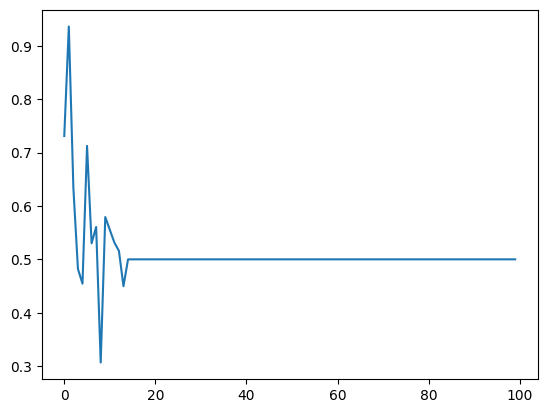

In [ ]:
plt.plot(probs[-1])

In [ ]:
save_rewards

array([[1., 2., 5., ..., 3., 4., 4.],
       [4., 3., 3., ..., 4., 2., 6.],
       [2., 2., 4., ..., 2., 6., 2.],
       ...,
       [7., 8., 5., ..., 6., 6., 5.],
       [3., 3., 1., ..., 3., 5., 3.],
       [2., 4., 4., ..., 2., 4., 3.]])

[<matplotlib.lines.Line2D>]

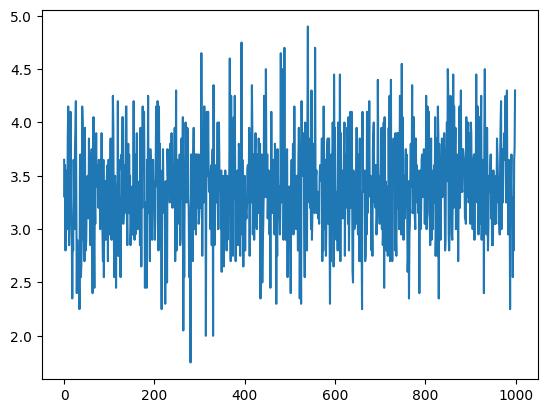

In [ ]:
plt.plot(save_rewards.mean(0))

Text(0, 0.5, 'Rolling Average Reward')

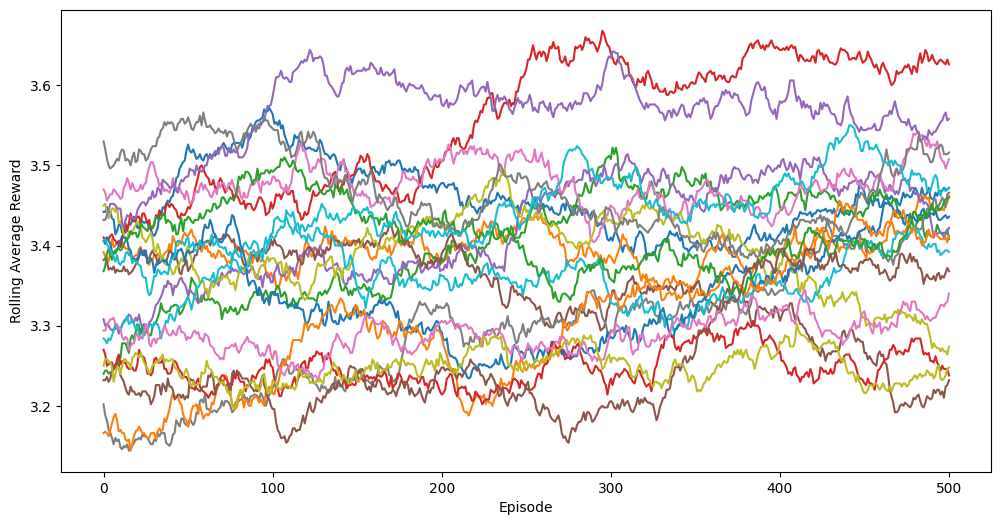

In [ ]:
# plot rolling average for the reward of each agent
window_size = 500
rolling_avg_rewards = np.zeros_like(save_rewards)[:, :-(window_size-1)]
for i in range(save_rewards.shape[0]):
    rolling_avg_rewards[i] = np.convolve(save_rewards[i], np.ones(window_size)/window_size, mode='valid')
plt.figure(figsize=(12, 6))
for i in range(save_rewards.shape[0]):
    plt.plot(rolling_avg_rewards[i], label=f'Agent {i+1}')
plt.xlabel('Episode')
plt.ylabel('Rolling Average Reward')



## Diagnostics & Tests

Targeted tests to verify each layer of the training pipeline independently.

| Test | What it checks |
|------|---------------|
| 1 | `check_encounter` fires/suppresses correctly |
| 2 | Reward rate with random policy (baseline / calibration) |
| 3 (`training_test_3`) | PS learning with a **proper 1D state space** – fixes the core issue |


In [ ]:

# ── Test 1: Encounter detection sanity check ─────────────────────────────
# Confirms check_encounter() fires when an agent is within radius r,
# and correctly returns 0 when it is far away.

_env_t1 = CollectiveEnv(num_agents=1, L=100.0, r=2.0, Nt=1, shared_depletion=True, tau=10000)
_env_t1.init_env()

# Agent placed exactly on the target
_env_t1.positions[0] = _env_t1.target_positions[0].copy()
_r1 = _env_t1.check_encounter()
print(f"[Test 1] Agent ON target           → reward = {_r1[0]:.0f}   (expected 1)")

# Reset availability, move agent far away
_env_t1.target_state[0] = -1.0
_env_t1.positions[0] = (_env_t1.target_positions[0] + np.array([50.0, 50.0])) % 100.0
_r2 = _env_t1.check_encounter()
print(f"[Test 1] Agent far from target     → reward = {_r2[0]:.0f}   (expected 0)")

# Place agent just inside the detection radius
_env_t1.target_state[0] = -1.0
_env_t1.positions[0] = _env_t1.target_positions[0] + np.array([1.9, 0.0])
_r3 = _env_t1.check_encounter()
print(f"[Test 1] Agent just inside r=2.0   → reward = {_r3[0]:.0f}   (expected 1)")


[Test 1] Agent ON target           → reward = 1   (expected 1)
[Test 1] Agent far from target     → reward = 0   (expected 0)
[Test 1] Agent just inside r=2.0   → reward = 1   (expected 1)


In [ ]:

# ── Test 2: Random-policy reward rate baseline ───────────────────────────
# Measures how many rewards/step a fully random policy achieves.
# This is the floor the trained policy must beat.
# Rough upper bound (no depletion, single agent): 2·r / L = 0.01 / agent·step.
# With shared depletion + 20 agents competing, the steady-state available fraction
# is lower, so the actual rate will be somewhat below 0.01.

@njit
def _random_policy_loop(episodes, time_ep, env):
    total = np.zeros(env.num_agents)
    for ep in range(episodes):
        env.init_env()
        for t in range(time_ep):
            env.update_target_state()
            actions = np.zeros(env.num_agents, dtype=np.bool_)
            for i in range(env.num_agents):
                actions[i] = np.random.randint(0, 2) == 1
            env.update_pos(actions)
            env.check_bc()
            total += env.check_encounter()
    return total

_ep2, _t2 = 300, 500
_env_t2 = CollectiveEnv(num_agents=20, L=100.0, r=0.5, Nt=100, shared_depletion=True, tau=10)
_rews_rnd = _random_policy_loop(_ep2, _t2, _env_t2)
_rate = _rews_rnd.mean() / (_ep2 * _t2)

print(f"[Test 2] Random policy rate:  {_rate:.5f}  rewards / agent·step")
print(f"         → ~{_rate * 500:.2f} rewards / agent per 500-step episode")
print(f"         Upper bound (no depletion, 2r/L): {2*0.5/100:.5f}")


[Test 2] Random policy rate:  0.00658  rewards / agent·step
         → ~3.29 rewards / agent per 500-step episode
         Upper bound (no depletion, 2r/L): 0.01000



### Fix: 1D state space + counter clipping  (`training_test_3`)

**Root cause of the low-reward signal:**

With `size_state_space = [max_counter, num_agents]` and `agents_spotted` always 0:
- `percept = counter × 1 + 0 × max_counter = counter` (the visual-cue dimension contributes nothing)
- `num_percepts = max_counter × num_agents = 50 × 20 = 1000`
- But only counters `0 … time_ep` are ever visited → at most 500 of the 1000 percepts are used
- Each visited h-matrix column receives `num_agents`-times fewer reward signals than it would with a proper 1D encoding  → dramatically slower PS convergence under sparse rewards

Additionally, when a counter exceeds `max_counter` (50) without turning, percept indices
≥ 50 are technically in the "visual-cue" slice of the state space; those h-matrix entries
start at `h = 1` (uniform) and get corrupted reinforcement, distorting the learned policy
for long runs.

**Fix applied in `training_test_3`:**

```python
size_state_space = np.array([max_counter])   # 1D → num_percepts = max_counter
counters = np.minimum(agents.get_state(), max_counter - 1)  # clip to valid range
observations = counters.reshape(-1, 1).astype(np.float64)
```

Minor remaining caveat: `check_encounter` uses Euclidean (not toroidal) distance while
`check_bc` uses periodic BC.  Near a wall, ~2·r/L ≈ 1 % of encounters are missed or
double‑counted.  This is a consistent environment quirk and does not prevent learning.


In [ ]:

@njit
def training_test_3(episodes, time_ep, env, agents, max_counter):
    """
    Like training_test_2 but with a proper 1D state space (counter only).

    Key differences vs training_test_2:
      - Requires Foragers created with size_state_space = np.array([max_counter]),
        so num_percepts = max_counter instead of max_counter * num_agents.
      - Counter is clipped to [0, max_counter-1] to prevent h_matrix index aliasing
        when an agent runs straight for more than max_counter steps.
    """
    save_rewards = np.zeros((agents.num_agents, episodes))

    for ep in range(episodes):
        env.init_env()
        agents.agent_states = np.zeros_like(agents.agent_states)
        agents.reset_g()

        for t in range(time_ep):
            env.update_target_state()

            # clip counter to stay inside the declared state space
            counters = np.minimum(agents.get_state(), np.int64(max_counter - 1))
            observations = counters.reshape(-1, 1).astype(np.float64)

            actions = agents.deliberate(observations)
            agents.act(actions)
            env.update_pos(actions == 1)
            env.check_bc()

            rewards = env.check_encounter()
            save_rewards[:, ep] += rewards
            agents.learn(rewards)

    return save_rewards, agents


In [ ]:

# ── Run training_test_3 ───────────────────────────────────────────────────
_n3      = 20
_max_c3  = 100                       # meaningful counter range
_size_ss3 = np.array([_max_c3])      # 1D: counter only  → num_percepts = 100

agents3 = Foragers(
    num_agents=_n3, num_actions=2, size_state_space=_size_ss3,
    gamma_damping=0.00001, eta_glow_damping=0.1,
)
env3 = CollectiveEnv(num_agents=_n3, L=100.0, r=0.5, Nt=100, shared_depletion=True, tau=10)

_ep3, _t3 = 2000, 500
_rews3, agents3 = training_test_3(_ep3, _t3, env3, agents3, _max_c3)

print(f"Mean reward  first 50 ep:   {_rews3[:, :50].mean():.3f}  / agent·ep")
print(f"Mean reward  last  50 ep:   {_rews3[:, -50:].mean():.3f}  / agent·ep")


Mean reward  first 50 ep:   3.304  / agent·ep
Mean reward  last  50 ep:   3.338  / agent·ep


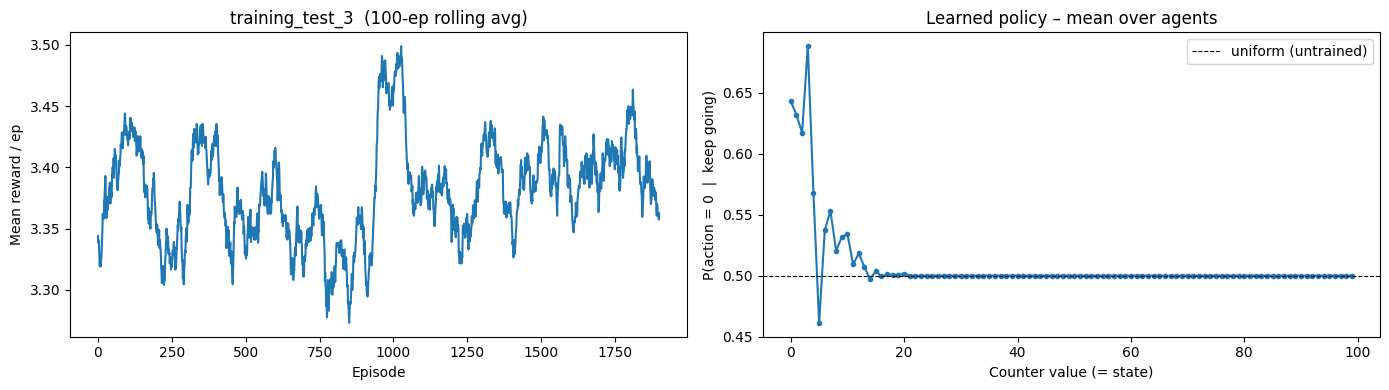

In [ ]:

# ── Plot training_test_3 results ─────────────────────────────────────────
fig3, ax3 = plt.subplots(1, 2, figsize=(14, 4))

_w3 = 100
_curve3 = _rews3.mean(0)
_roll3 = np.array([_curve3[i:i+_w3].mean() for i in range(len(_curve3) - _w3)])
ax3[0].plot(_roll3)
ax3[0].set_xlabel("Episode"); ax3[0].set_ylabel("Mean reward / ep")
ax3[0].set_title(f"training_test_3  ({_w3}-ep rolling avg)")

# P(keep-going | counter=k) — should deviate from 0.5 if learning worked
_p3 = agents3.h_matrix[:, 0, :_max_c3] / agents3.h_matrix[:, :, :_max_c3].sum(1)
ax3[1].plot(_p3.mean(0), 'o-', ms=3)
ax3[1].axhline(0.5, color='k', lw=0.8, ls='--', label='uniform (untrained)')
ax3[1].set_xlabel("Counter value (= state)")
ax3[1].set_ylabel("P(action = 0  |  keep going)")
ax3[1].set_title("Learned policy – mean over agents")
ax3[1].legend()

plt.tight_layout()
plt.show()



### Test 4 — counter reset at max_counter + biased prior h_0

Same as `training_test_3` (no visual cue) but:
- When `agent_states` reaches `max_counter` after `act()`, the counter is **reset to 0** (no hard clipping — the state machine just wraps back)
- `h_0` is initialised with a **strong bias toward action 0** (`keep going`): `h[:,0,:]= 0.99`, `h[:,1,:]=0.01`
- `initial_h_0 = True` so the PS damping term also pulls weights back toward this prior


In [ ]:

@njit
def training_test_4(episodes, time_ep, env, agents, max_counter):
    """
    No visual cue. Counter resets to 0 when it reaches max_counter (wrap, not clip).
    Intended to be used with a biased h_0 prior (initial_h_0=True).
    """
    save_rewards = np.zeros((agents.num_agents, episodes))

    for ep in range(episodes):
        env.init_env()
        agents.agent_states = np.zeros_like(agents.agent_states)
        agents.reset_g()

        for t in range(time_ep):
            env.update_target_state()

            # .copy() ensures contiguity — get_state() returns a jitclass view
            counters = agents.get_state().copy()
            observations = counters.reshape(-1, 1).astype(np.float64)

            actions = agents.deliberate(observations)
            agents.act(actions)

            # wrap: reset counter for agents that reached max_counter
            for i in range(agents.num_agents):
                if agents.agent_states[i] >= max_counter:
                    agents.agent_states[i] = 0

            env.update_pos(actions == 1)
            env.check_bc()

            rewards = env.check_encounter()
            save_rewards[:, ep] += rewards
            agents.learn(rewards)

    return save_rewards, agents


# ── setup ─────────────────────────────────────────────────────────────────
_n4      = 20
_max_c4  = 50
_size_ss4 = np.array([_max_c4])   # 1D: counter only

# biased prior: strongly favour action 0 (keep going), damping pulls back here
_h0_4 = np.zeros((_n4, 2, _max_c4))
_h0_4[:, 0, :] = 0.99   # action 0: keep going
_h0_4[:, 1, :] = 0.01   # action 1: turn

agents4 = Foragers(
    num_agents=_n4, num_actions=2, size_state_space=_size_ss4,
    gamma_damping=0.0001, eta_glow_damping=0.1,
    initial_h_0=True, h_0=_h0_4,
)
env4 = CollectiveEnv(num_agents=_n4, L=100.0, r=0.5, Nt=100, shared_depletion=True, tau=10)

_ep4, _t4 = 20000, 500
_rews4, agents4 = training_test_4(_ep4, _t4, env4, agents4, _max_c4)

print(f"Mean reward  first 50 ep:  {_rews4[:, :50].mean():.4f}  / agent·ep")
print(f"Mean reward  last  50 ep:  {_rews4[:, -50:].mean():.4f}  / agent·ep")
print(f"Improvement:               {(_rews4[:, -50:].mean() / (_rews4[:, :50].mean() + 1e-12)):.2f}x")


Mean reward  first 50 ep:  3.8380  / agent·ep
Mean reward  last  50 ep:  3.7500  / agent·ep
Improvement:               0.98x


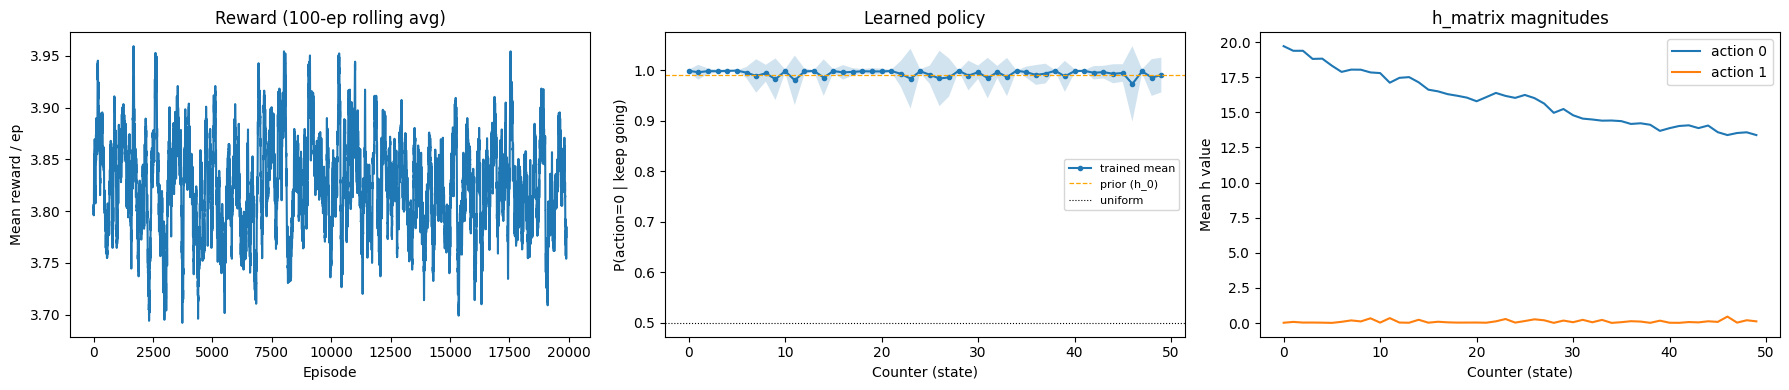

In [ ]:

fig4, axes4 = plt.subplots(1, 3, figsize=(18, 4))

# ── training curve ────────────────────────────────────────────────────────
_w4 = 100
_curve4 = _rews4.mean(0)
_roll4 = np.array([_curve4[i:i+_w4].mean() for i in range(len(_curve4) - _w4)])
axes4[0].plot(_roll4)
axes4[0].set_xlabel("Episode")
axes4[0].set_ylabel("Mean reward / ep")
axes4[0].set_title(f"Reward ({_w4}-ep rolling avg)")

# ── learned policy  P(keep-going | counter) ──────────────────────────────
_p4 = agents4.h_matrix[:, 0, :] / agents4.h_matrix.sum(1)   # shape (n_agents, max_counter)
axes4[1].plot(_p4.mean(0), 'o-', ms=3, label='trained mean')
axes4[1].fill_between(np.arange(_max_c4),
                       _p4.mean(0) - _p4.std(0),
                       _p4.mean(0) + _p4.std(0), alpha=0.2)
axes4[1].axhline(0.99, color='orange', lw=0.9, ls='--', label='prior (h_0)')
axes4[1].axhline(0.5,  color='k',      lw=0.8, ls=':',  label='uniform')
axes4[1].set_xlabel("Counter (state)")
axes4[1].set_ylabel("P(action=0 | keep going)")
axes4[1].set_title("Learned policy")
axes4[1].legend(fontsize=8)

# ── h_matrix magnitude (track if values grow or collapse) ────────────────
axes4[2].plot(agents4.h_matrix[:, 0, :].mean(0), label='action 0')
axes4[2].plot(agents4.h_matrix[:, 1, :].mean(0), label='action 1')
axes4[2].set_xlabel("Counter (state)")
axes4[2].set_ylabel("Mean h value")
axes4[2].set_title("h_matrix magnitudes")
axes4[2].legend()

plt.tight_layout()
plt.show()


# EXP 2

> Tests on single agents


## With Kick

In [ ]:
def read_log(filename):
    data_dict = {}
    with open(filename, 'r') as file:
        for line in file:
            line = line.strip()
            if line:
                key, value = line.split(":")
                data_dict[key.strip()] = value.strip()
    return data_dict

In [ ]:
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                
# @njit()
def train_loop_full_efficient(episodes, time_ep, agent, env, h_mat_allT = False):  

    if h_mat_allT: policy_t = np.zeros((episodes, agent.h_matrix.shape[-1]))
    save_rewards = np.zeros((episodes, time_ep))
    
    for ep in range(episodes):
        # print(f'starting episode {ep} for agent {n_agent}')
        #initialize environment and agent's counter and g matrix
        env.init_env()
        agent.agent_state = 0
        agent.reset_g()

        for t in range(time_ep):
            agent.N_upd_H += 1
            agent.N_upd_G += 1
            
            #step to set counter to its min value n=1
            if t == 0 or env.kicked[0]:
                #do one step with random direction (no learning in this step)
                env.update_pos(1)
                #check boundary conditions
                env.check_bc()
                #reset counter
                agent.agent_state = 0
                #set kicked value to false again
                env.kicked[0] = 0
                reward = 0

            else:
                #get perception
                state = agent.get_state()
                #decide
                action = agent.deliberate(state)
                #act (update counter)
                agent.act(action)

                #update positions
                env.update_pos(action)
                #check if target was found + kick if it is
                reward = env.check_encounter()

                #check boundary conditions
                env.check_bc()
                #learn
                if reward == 1:
                    agent._learn_post_reward(reward)

            if agent.N_upd_H == agent.max_no_H_update-1:
                agent._learn_post_reward(reward)
            
                

            # Saving
            save_rewards[ep, t] = reward
            
        if h_mat_allT: policy_t[ep] = agent.h_matrix[0,:] / agent.h_matrix.sum(0)
      
    return (save_rewards, policy_t) if h_mat_allT else (save_rewards, agent.h_matrix)

In [ ]:
Nt = 100; L = 100; r = 0.5; tau = 5
episodes = 10; time_ep = 20

env = TargetEnv(Nt = Nt, L = L, r = r, lc = np.array([[1.],[0.]]))
gamma_damping = 0.00001
eta_glow_damping = 0.1
agent = Forager(num_actions=2, size_state_space=np.array([10]), gamma_damping=gamma_damping, eta_glow_damping=eta_glow_damping)



In [ ]:
 
@njit(parallel = True)
def run_agents(episodes, time_ep, N_agents,
               # Environment props
               Nt = 100,
               L = 100,
               r = 0.5,
               lc = np.array([[1.0],[1]]),
               num_agents = 1, 
               agent_step = 1,
               destructive_targets = False,
               lc_distribution = 'constant',
               # Agent props
               num_actions = 2,
               state_space = np.array([np.linspace(0, 99, 100)]),
               gamma_damping = 0.00001,
               eta_glow_damping = 0.1,
               initial_prob_distr = np.array([[],[]]),
               policy_type = 'standard', 
               beta_softmax = 3,  
               fixed_policy = np.array([[],[]]),
               max_no_H_update = int(1e3),
               efficient_agent = False,
               h_mat_allT = False
              ):
    
    save_rewards = np.zeros((N_agents, episodes))
    if h_mat_allT:
        save_h_matrix = np.zeros((N_agents, episodes, state_space[0]))  
    else:        
        save_h_matrix = np.zeros((N_agents, 2, state_space[0])) 

    
    for n_agent in prange(N_agents):

        env = TargetEnv(Nt,L,r,lc,agent_step,num_agents,destructive_targets,lc_distribution)
        
        agent = Forager(num_actions,state_space,gamma_damping,
                                    eta_glow_damping,policy_type,beta_softmax,
                                    initial_prob_distr,fixed_policy,max_no_H_update,'s')
        rews, mat = train_loop_full_efficient(episodes, time_ep, agent, env, h_mat_allT) 
    
        for t in range(episodes):
            save_rewards[n_agent, t] = np.mean(rews[t])
        save_h_matrix[n_agent] = mat
        
    return save_rewards, save_h_matrix

In [ ]:
# Other similar exps: 'previous', 'previous_long'
# Current exp:
EXP = 'previous_pol_t'

# Training spec
TIME_EP = 5000
EPISODES = 1200
multiplier_agents = 5

# Environment 
Nt = 100; L = 100; r = 0.5; 
lc_distribution = 'constant'
lcs = [0.6]+np.linspace(1,10,10).tolist()

# Agent
max_counter = int(2e3)
state_space = np.array([max_counter])
gamma_damping = 0.00001
eta_glow_damping = 0.1
initial_prob_distr = (np.array([0.99, 0.01])*np.ones((2, max_counter)).transpose()).transpose()

In [ ]:
rews, mats = run_agents(episodes = EPISODES, time_ep = TIME_EP, N_agents = multiplier_agents*numba.get_num_threads(),
                        Nt = Nt, L = L, r = r, 
                        lc = np.array([[lcs[0]],[1.0]]), lc_distribution = lc_distribution,
                        state_space = state_space,
                        gamma_damping = gamma_damping,
                        eta_glow_damping = eta_glow_damping, 
                        initial_prob_distr = initial_prob_distr,
                        efficient_agent = True
                           )

[<matplotlib.lines.Line2D>]

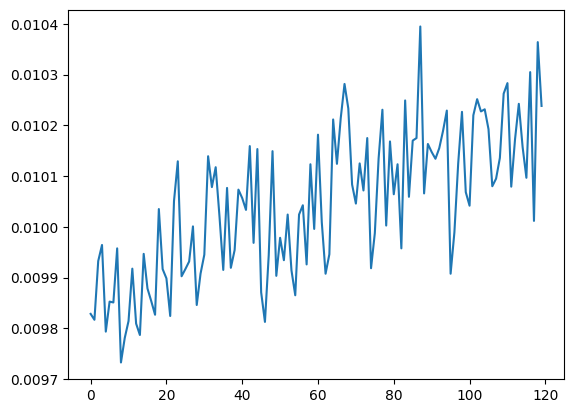

In [ ]:
plt.plot(rews.mean(0))

## With time delay

In [ ]:
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                
# @njit()
def train_loop_time_delay(episodes, time_ep, agent, env, h_mat_allT = False):  

    if h_mat_allT: policy_t = np.zeros((episodes, agent.h_matrix.shape[-1]))
    save_rewards = np.zeros((episodes, time_ep))
    
    for ep in range(episodes):
        # print(f'starting episode {ep} for agent {n_agent}')
        #initialize environment and agent's counter and g matrix
        env.init_env()
        agent.agent_state = 0
        agent.reset_g()
        agent_rewarded = False
        

        for t in range(time_ep):
            agent.N_upd_H += 1
            agent.N_upd_G += 1

            env.update_target_state()
            
            #step to set counter to its min value n=1
            if t == 0 or agent_rewarded:
                #do one step with random direction (no learning in this step)
                env.update_pos(1)
                #check boundary conditions
                env.check_bc()
                #reset counter
                agent.agent_state = 0
                #set kicked value to false again
                env.kicked[0] = 0
                reward = 0
                agent_rewarded = False

            else:
                #get perception
                state = agent.get_state()
                #decide
                action = agent.deliberate(state)
                #act (update counter)
                agent.act(action)

                #update positions
                env.update_pos(action)
                #check if target was found + kick if it is
                reward = env.check_encounter()

                #check boundary conditions
                env.check_bc()

                #learn
                if reward == 1:                    
                    agent._learn_post_reward(reward)
                    agent_rewarded = True

                # print(np.argwhere(env.target_state != -1), agent.get_state(), action, agent.h_matrix[0,:3])

            if agent.N_upd_H == agent.max_no_H_update-1:
                agent._learn_post_reward(reward)
            
                

            # Saving
            save_rewards[ep, t] = reward
            
        if h_mat_allT: policy_t[ep] = agent.h_matrix[0,:] / agent.h_matrix.sum(0)
      
    return (save_rewards, policy_t) if h_mat_allT else (save_rewards, agent.h_matrix)

In [ ]:
Nt = 100; L = 100; r = 0.5; tau = 5
episodes = 10; time_ep = 20

env = TargetEnv_timedelay(Nt = Nt, L = L, r = r, tau = tau)
gamma_damping = 0.00001
eta_glow_damping = 0.1
agent = Forager(num_actions=2, size_state_space=np.array([10]), gamma_damping=gamma_damping, eta_glow_damping=eta_glow_damping)
res = train_loop_time_delay(episodes, time_ep, agent, env, h_mat_allT = False)

[] [0] 1 [1. 1. 1.]
[] [1] 0 [1. 1. 1.]
[] [2] 0 [1. 1. 1.]
[] [0] 1 [1. 1. 1.]
[] [1] 0 [1. 1. 1.]
[] [2] 0 [1. 1. 1.]
[] [3] 0 [1. 1. 1.]
[] [0] 1 [1. 1. 1.]
[] [0] 1 [1. 1. 1.]
[] [0] 1 [1. 1. 1.]
[] [0] 1 [1. 1. 1.]
[] [0] 1 [1. 1. 1.]
[] [1] 0 [1. 1. 1.]
[] [2] 0 [1. 1. 1.]
[] [3] 0 [1. 1. 1.]
[] [0] 1 [1. 1. 1.]
[] [0] 1 [1. 1. 1.]
[] [1] 0 [1. 1. 1.]
[] [0] 1 [1. 1. 1.]
[] [1] 0 [1. 1. 1.]
[] [2] 0 [1. 1. 1.]
[] [3] 0 [1. 1. 1.]
[] [0] 1 [1. 1. 1.]
[] [1] 0 [1. 1. 1.]
[] [2] 0 [1. 1. 1.]
[] [3] 0 [1. 1. 1.]
[] [4] 0 [1. 1. 1.]
[] [5] 0 [1. 1. 1.]
[] [6] 0 [1. 1. 1.]
[] [7] 0 [1. 1. 1.]
[] [8] 0 [1. 1. 1.]
[] [0] 1 [1. 1. 1.]
[] [0] 1 [1. 1. 1.]
[] [0] 1 [1. 1. 1.]
[] [1] 0 [1. 1. 1.]
[] [2] 0 [1. 1. 1.]
[] [0] 1 [1. 1. 1.]
[] [1] 0 [1. 1. 1.]
[] [0] 1 [1. 1. 1.]
[] [0] 1 [1. 1. 1.]
[] [0] 1 [1. 1. 1.]
[] [1] 0 [1. 1. 1.]
[] [0] 1 [1. 1. 1.]
[] [1] 0 [1. 1. 1.]
[] [0] 1 [1. 1. 1.]
[] [0] 1 [1. 1. 1.]
[] [0] 1 [1. 1. 1.]
[] [0] 1 [1. 1. 1.]
[] [0] 1 [1. 1. 1.]
[] [0] 1 [1. 1. 1.]


In [ ]:
 
@njit(parallel = True)
def run_agents_time_delay(episodes, time_ep, N_agents,
               # Environment props
               Nt = 100,
               L = 100,
               r = 0.5,
               tau = 5,
               num_agents = 1, 
               agent_step = 1,
               # Agent props
               num_actions = 2,
               state_space = np.array([np.linspace(0, 99, 100)]),
               gamma_damping = 0.00001,
               eta_glow_damping = 0.1,
               initial_prob_distr = np.array([[],[]]),
               policy_type = 'standard', 
               beta_softmax = 3,  
               fixed_policy = np.array([[],[]]),
               max_no_H_update = int(1e3),
               h_mat_allT = False
              ):
    
    save_rewards = np.zeros((N_agents, episodes))
    if h_mat_allT:
        save_h_matrix = np.zeros((N_agents, episodes, state_space[0]))  
    else:        
        save_h_matrix = np.zeros((N_agents, 2, state_space[0])) 

    
    for n_agent in prange(N_agents):

        env = TargetEnv_timedelay(Nt, L, r, agent_step, num_agents,tau)

        agent = Forager(num_actions,state_space,gamma_damping,
                                    eta_glow_damping,policy_type,beta_softmax,
                                    initial_prob_distr,fixed_policy,max_no_H_update,'s')
        
        rews, mat = train_loop_time_delay(episodes, time_ep, agent, env, h_mat_allT) 
    
        for t in range(episodes):
            save_rewards[n_agent, t] = np.mean(rews[t])
        save_h_matrix[n_agent] = mat
        
    return save_rewards, save_h_matrix

In [ ]:
# Training spec
TIME_EP = 5000
EPISODES = 200
multiplier_agents = 10

# Environment 
Nt = 100; L = 100; r = 0.5; tau = 3

# Agent
max_counter = int(2e3)
state_space = np.array([max_counter])
gamma_damping = 0.00001
eta_glow_damping = 0.1
# initial_prob_distr = (np.array([0.99, 0.01])*np.ones((2, max_counter)).transpose()).transpose()
initial_prob_distr = (np.array([0.5, 0.5])*np.ones((2, max_counter)).transpose()).transpose()

In [ ]:
rews, mats = run_agents_time_delay(episodes = EPISODES, time_ep = TIME_EP, N_agents = multiplier_agents*numba.get_num_threads(),
                        Nt = Nt, L = L, r = r, tau = tau,
                        state_space = state_space,
                        gamma_damping = gamma_damping,
                        eta_glow_damping = eta_glow_damping, 
                        initial_prob_distr = initial_prob_distr
                           )

[<matplotlib.lines.Line2D>]

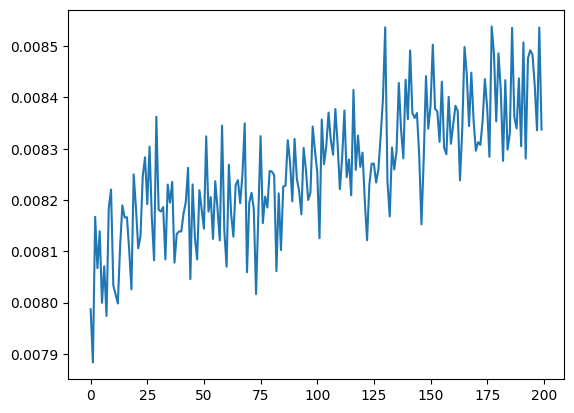

In [ ]:
plt.plot(rews.mean(0))

[<matplotlib.lines.Line2D>]

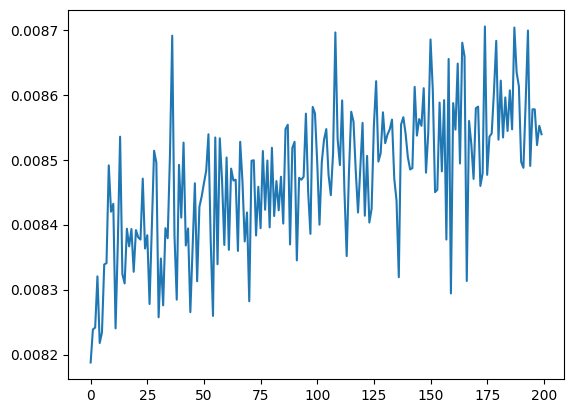

In [ ]:
plt.plot(rews.mean(0))

[<matplotlib.lines.Line2D>]

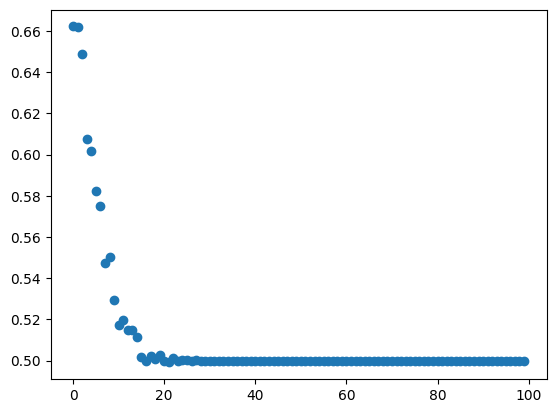

In [ ]:
probs = mats[:,0,:100] / mats[:,:,:100].sum(1)

plt.plot(probs.mean(0), 'o')

## With check encounter simplified

In [ ]:
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                
@njit()
def train_loop_time_delay_encounter_simp(episodes, time_ep, agent, env, h_mat_allT = False):  

    if h_mat_allT: policy_t = np.zeros((episodes, agent.h_matrix.shape[-1]))
    save_rewards = np.zeros((episodes, time_ep))
    
    for ep in range(episodes):
        # print(f'starting episode {ep} for agent {n_agent}')
        #initialize environment and agent's counter and g matrix
        env.init_env()
        agent.agent_state = 0
        agent.reset_g()
        agent_rewarded = False
        

        for t in range(time_ep):
            agent.N_upd_H += 1
            agent.N_upd_G += 1

            env.update_target_state()
            
            #step to set counter to its min value n=1
            if t == 0 or agent_rewarded:
                #do one step with random direction (no learning in this step)
                env.update_pos(1)
                #check boundary conditions
                env.check_bc()
                #reset counter
                agent.agent_state = 0
                #set kicked value to false again
                env.kicked[0] = 0
                reward = 0
                agent_rewarded = False

            else:
                #get perception
                state = agent.get_state()
                #decide
                action = agent.deliberate(state)
                #act (update counter)
                agent.act(action)

                #update positions
                env.update_pos(action)
                #check if target was found + kick if it is
                reward = env.check_encounter_simplified()

                #check boundary conditions
                env.check_bc()

                #learn
                if reward == 1:                    
                    agent._learn_post_reward(reward)
                    agent_rewarded = True

                # print(np.argwhere(env.target_state != -1), agent.get_state(), action, agent.h_matrix[0,:3])

            if agent.N_upd_H == agent.max_no_H_update-1:
                agent._learn_post_reward(reward)
            
                

            # Saving
            save_rewards[ep, t] = reward
            
        if h_mat_allT: policy_t[ep] = agent.h_matrix[0,:] / agent.h_matrix.sum(0)
      
    return (save_rewards, policy_t) if h_mat_allT else (save_rewards, agent.h_matrix)

In [ ]:
 
@njit(parallel = True)
def run_agents_time_delay_encounter_simp(episodes, time_ep, N_agents,
               # Environment props
               Nt = 100,
               L = 100,
               r = 0.5,
               tau = 5,
               num_agents = 1, 
               agent_step = 1,
               # Agent props
               num_actions = 2,
               state_space = np.array([np.linspace(0, 99, 100)]),
               gamma_damping = 0.00001,
               eta_glow_damping = 0.1,
               initial_prob_distr = np.array([[],[]]),
               policy_type = 'standard', 
               beta_softmax = 3,  
               fixed_policy = np.array([[],[]]),
               max_no_H_update = int(1e3),
               h_mat_allT = False
              ):
    
    save_rewards = np.zeros((N_agents, episodes))
    if h_mat_allT:
        save_h_matrix = np.zeros((N_agents, episodes, state_space[0]))  
    else:        
        save_h_matrix = np.zeros((N_agents, 2, state_space[0])) 

    
    for n_agent in prange(N_agents):

        env = TargetEnv_timedelay(Nt, L, r, agent_step, num_agents,tau)

        agent = Forager(num_actions,state_space,gamma_damping,
                                    eta_glow_damping,policy_type,beta_softmax,
                                    initial_prob_distr,fixed_policy,max_no_H_update,'s')
        
        rews, mat = train_loop_time_delay_encounter_simp(episodes, time_ep, agent, env, h_mat_allT) 
    
        for t in range(episodes):
            save_rewards[n_agent, t] = np.mean(rews[t])
        save_h_matrix[n_agent] = mat
        
    return save_rewards, save_h_matrix

In [ ]:
# Training spec
TIME_EP = 5000
EPISODES = 200
multiplier_agents = 10

# Environment 
Nt = 100; L = 100; r = 1; tau = 2

# Agent
max_counter = int(2e3)
state_space = np.array([max_counter])
gamma_damping = 0.00001
eta_glow_damping = 0.1
# initial_prob_distr = (np.array([0.99, 0.01])*np.ones((2, max_counter)).transpose()).transpose()
initial_prob_distr = (np.array([0.5, 0.5])*np.ones((2, max_counter)).transpose()).transpose()

In [ ]:
rews, mats = run_agents_time_delay_encounter_simp(episodes = EPISODES, time_ep = TIME_EP, N_agents = multiplier_agents*numba.get_num_threads(),
                        Nt = Nt, L = L, r = r, tau = tau,
                        state_space = state_space,
                        gamma_damping = gamma_damping,
                        eta_glow_damping = eta_glow_damping, 
                        initial_prob_distr = initial_prob_distr
                           )

[<matplotlib.lines.Line2D>]

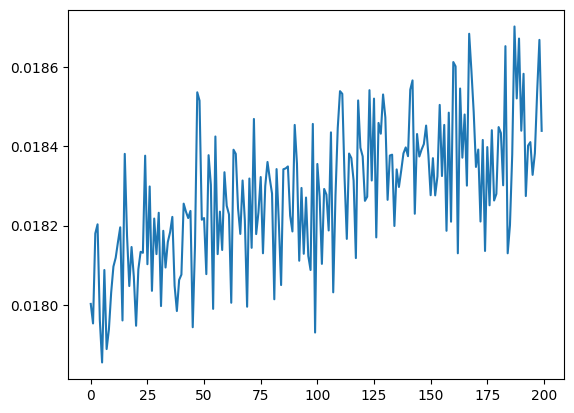

In [ ]:
plt.plot(rews.mean(0))

# EXP 3
> Making training loop for collective working: using fix on Exp 2 to Exp 1

In [ ]:
@njit
def training_test_3(episodes, time_ep, env, agents): 

    save_rewards = np.zeros((agents.num_agents,episodes))

    agents_spotted = np.zeros_like(env.agents_in_cone())

    agents_rewarded = np.zeros(agents.num_agents, dtype=np.bool_)

    for ep in range(episodes):
        
        # initialize environment and agent's counter and g matrix
        env.init_env()
        
        agents.agent_states = np.zeros_like(agents.agent_states)
        agents.reset_g()

        for t in range(time_ep):
            
            env.update_target_state()

            counters = agents.get_state()
            observations = np.vstack((counters, agents_spotted)).T.astype(np.float64)

            actions = agents.deliberate(observations)

            # Post-reward step: override BEFORE act — turn + reset
            actions[agents_rewarded] = 1           # force TURN (not 0)
            agents.agent_states[agents_rewarded] = 0  # reset counter

            agents.act(actions)
            env.update_pos(actions == 1)
            env.check_bc()

            rewards = env.check_encounter()
            rewards[agents_rewarded] = 0  # suppress double reward

            save_rewards[:, ep] += rewards
            agents.learn(rewards)

            agents_rewarded = rewards == 1

    return save_rewards, agents.h_matrix

In [ ]:
@njit(parallel = True)
def run_collective(episodes, time_ep, runs,
               # Environment props
               Nt = 100,
               L = 100,
               r = 0.5,
               tau = 5,
               num_agents = 1,
               agent_step: int = 1,
                visual_range: float = 2,
                visual_angle: float = np.pi / 2,
                shared_depletion: bool = True,
               # Agent props
               num_actions = 2,
               state_space = np.array([50, 30]),
               gamma_damping = 0.00001,
               eta_glow_damping = 0.1,
               initial_h_0: bool = False,
                h_0 = np.array([[[], [], []]]),
                g_update: str = 's',
               policy_type = 'standard', 
               beta_softmax = 3
              ):
    
    
    save_h_matrix = np.zeros((runs, num_agents, num_actions, state_space.prod()))    
    save_rewards = np.zeros((runs, num_agents, episodes))
    
    for n_run in prange(runs):

        env = TargetEnv_timedelay(Nt, L, r, agent_step, num_agents,tau)

        # agent = Forager(num_actions,state_space,gamma_damping,
        #                             eta_glow_damping,policy_type,beta_softmax,
        #                             initial_prob_distr,fixed_policy,max_no_H_update,'s')



        agents = Foragers(num_agents, num_actions, state_space,
                          gamma_damping, eta_glow_damping, policy_type, beta_softmax, initial_h_0, h_0, g_update)
    
        env = CollectiveEnv( num_agents, Nt, L, r, tau, agent_step, visual_range, visual_angle, shared_depletion)

      
        
        rews, mat = training_test_3(episodes, time_ep, env, agents)
        
        for t in range(episodes):
            save_rewards[n_run, :, t] = np.mean(rews[:, t])
        save_h_matrix[n_run] = mat
        
    return save_rewards, save_h_matrix

In [ ]:
res = run_collective(episodes = 10, time_ep = 5, runs = 3, num_agents = 6)

In [ ]:
num_agents = 50
max_counter = 50
runs = 5

Nt = 100; L = 100; r = 1; tau = 1
gamma_damping = 0.00001
eta_glow_damping = 0.1

size_state_space = np.array([max_counter, num_agents])
agents = Foragers(num_agents = num_agents, num_actions = 2, size_state_space = size_state_space, 
                  gamma_damping = gamma_damping, eta_glow_damping = eta_glow_damping) 
env = CollectiveEnv(num_agents = num_agents, Nt = Nt, L = L, r = r, tau = tau, shared_depletion = True)

In [ ]:
time_ep = 5000
episodes = 200

res = run_collective(episodes = episodes, time_ep = time_ep, runs = runs*numba.get_num_threads(), 
                     num_agents = 6, Nt = Nt, L = L, r = r, tau = tau,
                     state_space = size_state_space,
                     gamma_damping = gamma_damping,
                     eta_glow_damping = eta_glow_damping)

[<matplotlib.lines.Line2D>]

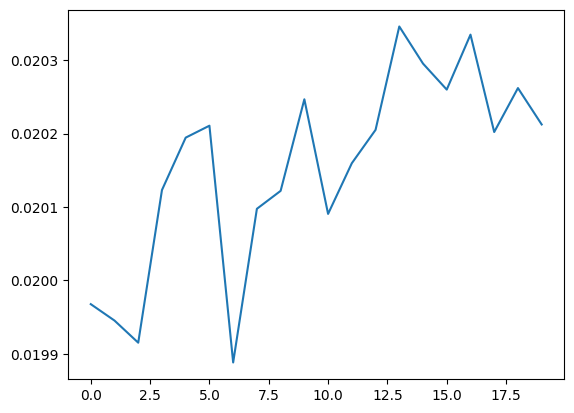

In [ ]:
plt.plot(res[0].mean(0).mean(0)/time_ep)

## EXP 3.1

### Efficient training loop (`Foragers_efficient`)

Same logic as `training_test_3` but uses the efficient H/G update strategy:

- `increment_counters()` called every step (increments the per-agent `N_upd_H` / `N_upd_G` counters)
- `_learn_post_reward(rewards)` called every step — is a **no-op** for agents that have neither received a reward nor hit `max_no_H_update`, so only rewarded agents pay the cost of the H/G flush
- The G-matrix is **not decayed globally** each step; only the visited `(agent, action, percept)` entry is touched (lazy decay)

In [ ]:
@njit
def training_test_3_efficient(episodes, time_ep, env, agents, max_counter):
    """
    Like training_test_3 but adapted for Foragers_efficient.

    Key differences vs training_test_3:
      - increment_counters() is called at the start of each timestep (tracks
        how many steps have passed since the last H/G update per agent).
      - _learn_post_reward(rewards) replaces learn(rewards). For agents that
        did NOT receive a reward and have NOT hit max_no_H_update, the call is
        a no-op — so only rewarded agents pay the cost of a full H/G flush.
      - The G-matrix is never decayed globally; only the visited
        (agent, action, percept) entry is touched per step (lazy decay).
      - .copy() on get_state() ensures a contiguous array for reshape().
    """
    save_rewards = np.zeros((agents.num_agents, episodes))
    agents_rewarded = np.zeros(agents.num_agents, dtype=np.bool_)

    for ep in range(episodes):
        env.init_env()
        agents.agent_states = np.zeros_like(agents.agent_states)
        agents.reset_g()

        for t in range(time_ep):

            agents.increment_counters()
            env.update_target_state()

            # clip counter to stay inside the declared state space
            counters = np.minimum(agents.get_state().copy(), np.int64(max_counter - 1))
            observations = counters.reshape(-1, 1).astype(np.float64)

            actions = agents.deliberate(observations)

            # Post-reward step: force turn + reset counter BEFORE act
            actions[agents_rewarded] = 1
            agents.agent_states[agents_rewarded] = 0

            agents.act(actions)
            env.update_pos(actions == 1)
            env.check_bc()

            rewards = env.check_encounter()
            rewards[agents_rewarded] = 0  # suppress double reward

            save_rewards[:, ep] += rewards
            agents._learn_post_reward(rewards)

            agents_rewarded = rewards == 1

    return save_rewards, agents.h_matrix


@njit(parallel=True)
def run_collective_efficient(episodes, time_ep, runs,
               # Environment props
               Nt=100,
               L=100,
               r=0.5,
               tau=5,
               num_agents=1,
               agent_step=1,
               visual_range=2.0,
               visual_angle=np.pi / 2,
               shared_depletion=True,
               # Agent props
               num_actions=2,
               state_space=np.array([50]),
               gamma_damping=0.00001,
               eta_glow_damping=0.1,
               initial_h_0=False,
               h_0=np.zeros((1, 2, 50)),
               g_update='s',
               policy_type='standard',
               beta_softmax=3,
               max_no_H_update=int(1e3),
              ):
    save_h_matrix = np.zeros((runs, num_agents, num_actions, state_space.prod()))
    save_rewards = np.zeros((runs, num_agents, episodes))

    for n_run in prange(runs):

        agents = Foragers_efficient(
            num_agents, num_actions, state_space,
            gamma_damping, eta_glow_damping, policy_type, beta_softmax,
            initial_h_0, h_0, g_update, max_no_H_update,
        )
        env = CollectiveEnv(num_agents, Nt, L, r, tau, agent_step, visual_range, visual_angle, shared_depletion)

        rews, mat = training_test_3_efficient(episodes, time_ep, env, agents, state_space[0])

        for t in range(episodes):
            save_rewards[n_run, :, t] = rews[:, t].mean()
        save_h_matrix[n_run] = mat

    return save_rewards, save_h_matrix

In [ ]:
num_agents = 50
max_counter = 50
runs = 5

Nt = 100; L = 100; r = 1; tau = 1
gamma_damping = 0.00001
eta_glow_damping = 0.1

size_state_space = np.array([max_counter, num_agents])

In [ ]:
time_ep = 5000
episodes = 200

res_effi = run_collective_efficient(
    episodes=episodes, time_ep=time_ep, runs=runs * numba.get_num_threads(),
    num_agents=6, Nt=Nt, L=L, r=r, tau=tau,
    state_space=np.array([max_counter]),
    gamma_damping=gamma_damping, eta_glow_damping=eta_glow_damping,
)

[<matplotlib.lines.Line2D>]

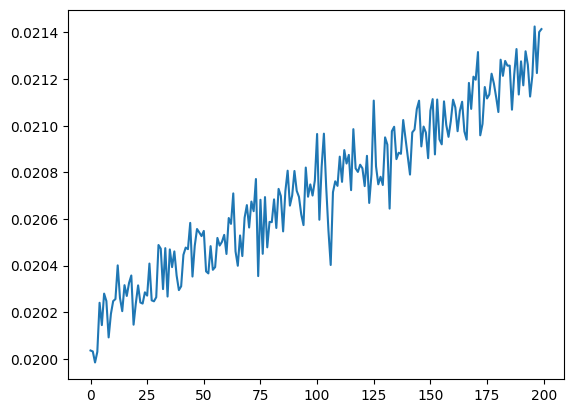

In [ ]:
plt.plot(res_effi[0].mean(0).mean(0)/time_ep)

[<matplotlib.lines.Line2D>]

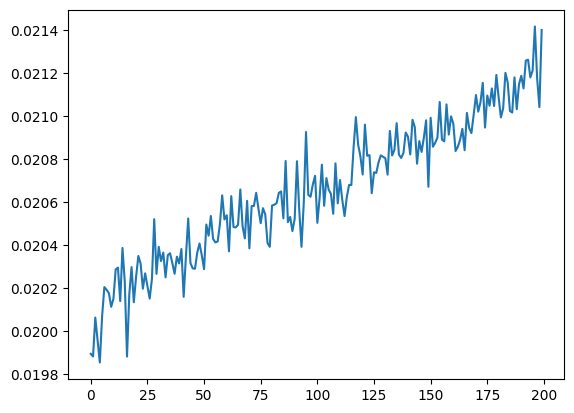

In [ ]:
plt.plot(res_effi[0].mean(0).mean(0)/time_ep)

### Longer runs

In [ ]:
import os

# Same base parameters as the last test
max_counter = 50
runs = 5
Nt = 100
L = 100
r = 1
time_ep = 5000
episodes = 2000
gamma_damping = 0.00001
eta_glow_damping = 0.1

taus = [1, 2, 3]
agent_counts = [5, 10, 20]

out_dir = "/home/gorka/github/rl_opts/nbs/lib_nbs/develop/results/exp_3"
os.makedirs(out_dir, exist_ok=True)

for tau in taus:
    for n_agents in agent_counts:
        size_state_space = np.array([max_counter, n_agents])

        save_rewards, save_h_matrix = run_collective(
            episodes=episodes,
            time_ep=time_ep,
            runs=runs * numba.get_num_threads(),
            num_agents=n_agents,
            Nt=Nt,
            L=L,
            r=r,
            tau=tau,
            state_space=size_state_space,
            gamma_damping=gamma_damping,
            eta_glow_damping=eta_glow_damping,
        )

        rewards_path = os.path.join(out_dir, f"save_rewards_tau{tau}_agents{n_agents}.npy")
        h_matrix_path = os.path.join(out_dir, f"save_h_matrix_tau{tau}_agents{n_agents}.npy")

        np.save(rewards_path, save_rewards)
        np.save(h_matrix_path, save_h_matrix)

        print(f"Saved tau={tau}, agents={n_agents} -> {rewards_path}, {h_matrix_path}")

Saved tau=1, agents=5 -> results/exp_3/save_rewards_tau1_agents5.npy, results/exp_3/save_h_matrix_tau1_agents5.npy
Saved tau=1, agents=10 -> results/exp_3/save_rewards_tau1_agents10.npy, results/exp_3/save_h_matrix_tau1_agents10.npy


SystemError: CPUDispatcher(<function run_collective at 0x78514b71e7a0>) returned a result with an exception set

<matplotlib.legend.Legend>

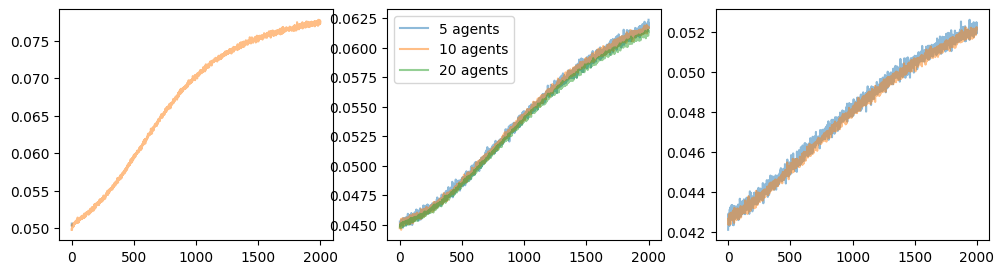

In [ ]:
folder_path = "/home/gorka/github/rl_opts/nbs/lib_nbs/develop/results/exp_3"
taus = [1, 2, 3]
agent_counts = [5, 10, 20]

fig, axs =  plt.subplots(1, len(taus), figsize = (4*len(taus), 3))

for idx, tau in enumerate(taus):
    for n_agents in agent_counts:

        try:
            rewards_path = os.path.join(folder_path, f"save_rewards_tau{tau}_agents{n_agents}.npy")
            h_matrix_path = os.path.join(folder_path, f"save_h_matrix_tau{tau}_agents{n_agents}.npy")

            save_rewards = np.load(rewards_path)
            save_h_matrix = np.load(h_matrix_path)

            axs[idx].plot(save_rewards.mean(0).mean(0)/time_ep, label = f"{n_agents} agents", alpha = 0.5)
        except:
            pass

axs[1].legend()

<matplotlib.legend.Legend>

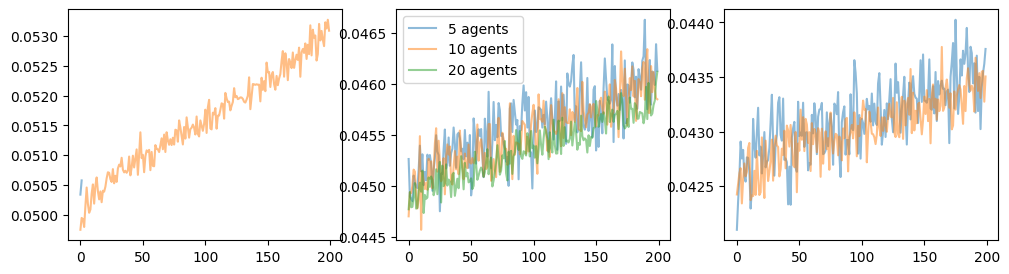

In [ ]:
folder_path = "/home/gorka/github/rl_opts/nbs/lib_nbs/develop/results/exp_3"

fig, axs =  plt.subplots(1, len(taus), figsize = (4*len(taus), 3))

for idx, tau in enumerate(taus):
    for n_agents in agent_counts:

        try:
            rewards_path = os.path.join(folder_path, f"save_rewards_tau{tau}_agents{n_agents}.npy")
            h_matrix_path = os.path.join(folder_path, f"save_h_matrix_tau{tau}_agents{n_agents}.npy")

            save_rewards = np.load(rewards_path)
            save_h_matrix = np.load(h_matrix_path)

            axs[idx].plot(save_rewards.mean(0).mean(0)[:200]/time_ep, label = f"{n_agents} agents", alpha = 0.5)
        except:
            pass

axs[1].legend()

/tmp/ipykernel_658587/427650497.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


<matplotlib.legend.Legend>

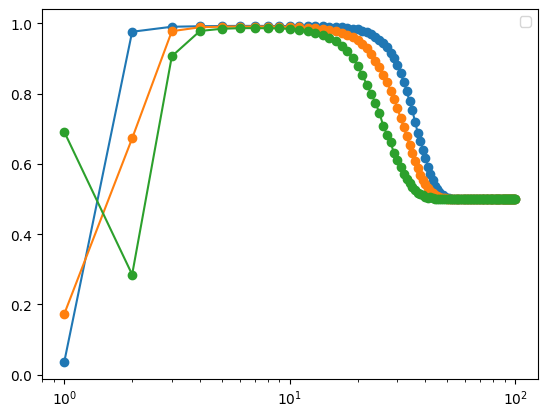

In [ ]:
folder_path = "/home/gorka/github/rl_opts/nbs/lib_nbs/develop/results/exp_3"

fig, axs =  plt.subplots()


for idx, tau in enumerate(taus):

    if idx == 2:
        n_agents = 10
    else: 
        n_agents = 20

    h_matrix_path = os.path.join(folder_path, f"save_h_matrix_tau{tau}_agents{n_agents}.npy")

    save_h_matrix = np.load(h_matrix_path)

    probs = save_h_matrix[:,:,0,:100] / save_h_matrix[:,:,:,:100].sum(-2)

    plt.semilogx(np.arange(1, probs.shape[-1]+1), probs.mean(0).mean(0), '-o')

plt.legend()

# EXP 4
> Testing visual cone: agents are rewarded if they see another agent. Goal is to see if they continue with more agents in front

### EXP 4.1 — Reward from `agents_in_cone` only

Setup:
- Counter is **always fixed to 0** (no counter dynamics).
- Observation uses `[counter=0, agents_in_cone]`.
- Reward is **1** when `agents_in_cone == 0`, else **0**.
- This tests whether the visual-cone occupancy signal alone can drive learning.

In [ ]:
@njit
def training_test_4_efficient(episodes, time_ep, env, agents):
    """
    EXP 4.1 (efficient)
    Reward depends only on visual-cone occupancy:
      reward_i = 1 if agents_in_cone_i == 0 else 0.

    Counter is fixed to 0 for all agents at all times.
    Uses Foragers_efficient with lazy G updates and _learn_post_reward().
    """
    save_rewards = np.zeros((agents.num_agents, episodes))

    # Fixed first feature (counter): always zero.
    counters = np.zeros(agents.num_agents, dtype=np.float64)

    for ep in range(episodes):
        env.init_env()
        agents.agent_states = np.zeros_like(agents.agent_states)
        agents.reset_g()

        for t in range(time_ep):
            # Required by Foragers_efficient timing of lazy H/G updates.
            agents.increment_counters()

            # Keep internal counter fixed.
            agents.agent_states[:] = 0

            # Observation = [counter=0, agents_in_cone].
            agents_spotted = env.agents_in_cone().astype(np.float64)
            observations = np.vstack((counters, agents_spotted)).T

            actions = agents.deliberate(observations)

            # Do not call agents.act(actions): counter must remain fixed.
            env.update_pos(actions == 1)
            env.check_bc()

            # Reward from post-move cone occupancy only.
            agents_spotted_after = env.agents_in_cone()
            rewards = (agents_spotted_after != 0).astype(np.float64)

            save_rewards[:, ep] += rewards

            # Efficient learning step: only rewarded agents are effectively flushed.
            agents._learn_post_reward(rewards)

            # Enforce fixed counter constraint.
            agents.agent_states[:] = 0

    return save_rewards, agents.h_matrix


@njit(parallel=True)
def run_collective_cone_efficient(episodes, time_ep, runs,
                                  # Environment props
                                  Nt=100,
                                  L=100,
                                  r=0.5,
                                  tau=5,
                                  num_agents=10,
                                  agent_step=1,
                                  visual_range=2.0,
                                  visual_angle=np.pi / 2,
                                  shared_depletion=False,
                                  # Agent props
                                  num_actions=2,
                                  state_space=np.array([1, 30]),
                                  gamma_damping=0.00001,
                                  eta_glow_damping=0.1,
                                  initial_h_0=False,
                                  h_0=np.zeros((1, 2, 30)),
                                  g_update='s',
                                  policy_type='standard',
                                  beta_softmax=3,
                                  max_no_H_update=int(1e3)):
    """
    Parallel launcher for EXP 4.1 using Foragers_efficient.

    Important:
      - Use state_space[0] = 1 (counter fixed to 0).
      - Use state_space[1] >= max possible value of agents_in_cone + 1.
        A safe choice is num_agents + 1.
    """
    save_h_matrix = np.zeros((runs, num_agents, num_actions, state_space.prod()))
    save_rewards = np.zeros((runs, num_agents, episodes))

    for n_run in prange(runs):
        agents = Foragers_efficient(
            num_agents, num_actions, state_space,
            gamma_damping, eta_glow_damping, policy_type, beta_softmax,
            initial_h_0, h_0, g_update, max_no_H_update,
        )

        env = CollectiveEnv(num_agents, Nt, L, r, tau, agent_step,
                            visual_range, visual_angle, shared_depletion)

        rews, mat = training_test_4_efficient(episodes, time_ep, env, agents)

        for t in range(episodes):
            save_rewards[n_run, :, t] = rews[:, t]
        save_h_matrix[n_run] = mat

    return save_rewards, save_h_matrix

In [ ]:
# Quick run for EXP 4.1 (efficient)
num_agents = 50
max_counter = 1  # fixed counter => only state 0 is used
runs = 1

Nt = 100; L = 50; r = 1.0; tau = 1
gamma_damping = 0.00001
eta_glow_damping = 0.1

# Features: [counter, agents_in_cone]
# counter has 1 state (always 0), cone count uses num_agents+1 bins (0..num_agents)
state_space_cone = np.array([max_counter, num_agents + 1])

time_ep = 2000
episodes = 200

res_cone_eff = run_collective_cone_efficient(
    episodes=episodes,
    time_ep=time_ep,
    runs=20,#runs * numba.get_num_threads(),
    num_agents=num_agents,
    Nt=Nt,
    L=L,
    r=r,
    tau=tau,
    state_space=state_space_cone,
    gamma_damping=gamma_damping,
    eta_glow_damping=eta_glow_damping,
    shared_depletion=False,
)


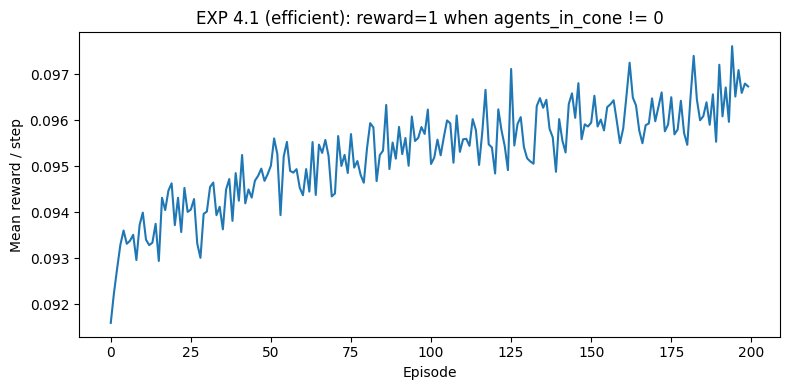

In [ ]:

plt.figure(figsize=(8, 4))
plt.plot(res_cone_eff[0].mean(0).mean(0) / time_ep)
plt.xlabel('Episode')
plt.ylabel('Mean reward / step')
plt.title('EXP 4.1 (efficient): reward=1 when agents_in_cone != 0')
plt.tight_layout()
plt.show()

Text(0, 0.5, 'P(continue)')

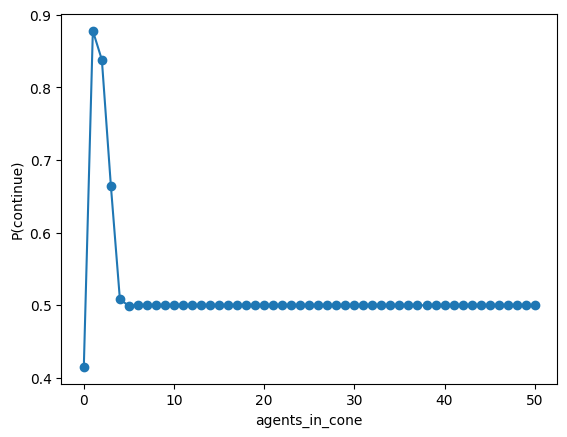

In [ ]:
hmats = res_cone_eff[1].reshape(20*50, 2, -1)
probs = hmats[:,0] / hmats.sum(-2)

plt.plot(probs.mean(0), '-o'   )
plt.xlabel('agents_in_cone')
plt.ylabel('P(continue)')

## EXP 4.2
> Testing the same as above but considering only rewarded agents (we put a lot of targets) and with new `env.step` function

In [ ]:
@njit
def training_test_4_2(episodes, time_ep, env, agents):
    """
    EXP 4.2
    Reward depends on seeing rewarded agents in the cone:
      reward_i = 1 if agent i sees at least one agent with env.rewarded_agents == 1.

    Counter is fixed to 0 for all agents at all times.
    Uses Foragers_efficient with lazy G updates and _learn_post_reward().
    """
    save_rewards = np.zeros((agents.num_agents, episodes))

    # Fixed first feature (counter): always zero.
    counters = np.zeros(agents.num_agents, dtype=np.float64)

    for ep in range(episodes):
        env.init_env()
        agents.agent_states = np.zeros_like(agents.agent_states)
        agents.reset_g()

        for t in range(time_ep):
            # Required by Foragers_efficient timing of lazy H/G updates.
            agents.increment_counters()

            # Keep internal counter fixed.
            agents.agent_states[:] = 0

            # Observation = [counter=0, agents_in_cone].
            agents_spotted, _ = env.agents_in_cone()
            observations = np.vstack((counters, agents_spotted.astype(np.float64))).T

            actions = agents.deliberate(observations)

            # Do not call agents.act(actions): counter must remain fixed.
            env.step(actions == 1)

            # Reward: 1 if agent sees at least one currently-rewarded agent in its cone.
            _, agents_spot = env.agents_in_cone()
            # agents_spot[i, j] == 1 means agent j is in agent i's cone
            # env.rewarded_agents[j] == 1 means agent j is currently rewarded
            rewarded_in_cone = (agents_spot * env.rewarded_agents[np.newaxis, :]).sum(axis=1)
            rewards = (rewarded_in_cone > 0).astype(np.float64)

            save_rewards[:, ep] += rewards

            # Efficient learning step: only rewarded agents are effectively flushed.
            agents._learn_post_reward(rewards)

            # Enforce fixed counter constraint.
            agents.agent_states[:] = 0

    return save_rewards, agents.h_matrix


@njit(parallel=True)
def run_4_2(episodes, time_ep, runs,
                                  # Environment props
                                  Nt=100,
                                  L=100,
                                  r=0.5,
                                  tau=5,
                                  tau_reward=4,
                                  num_agents=10,
                                  agent_step=1,
                                  visual_range=2.0,
                                  visual_angle=np.pi / 2,
                                  shared_depletion=False,
                                  # Agent props
                                  num_actions=2,
                                  state_space=np.array([1, 30]),
                                  gamma_damping=0.00001,
                                  eta_glow_damping=0.1,
                                  initial_h_0=False,
                                  h_0=np.zeros((1, 2, 30)),
                                  g_update='s',
                                  policy_type='standard',
                                  beta_softmax=3,
                                  max_no_H_update=int(1e3)):
    """
    Parallel launcher for EXP 4.2 using Foragers_efficient.

    Important:
      - Use state_space[0] = 1 (counter fixed to 0).
      - Use state_space[1] >= max possible value of agents_in_cone + 1.
        A safe choice is num_agents + 1.
    """
    save_h_matrix = np.zeros((runs, num_agents, num_actions, state_space.prod()))
    save_rewards = np.zeros((runs, num_agents, episodes))

    for n_run in prange(runs):
        agents = Foragers_efficient(
            num_agents, num_actions, state_space,
            gamma_damping, eta_glow_damping, policy_type, beta_softmax,
            initial_h_0, h_0, g_update, max_no_H_update,
        )

        env = CollectiveEnv(num_agents, Nt, L, r, tau, agent_step,
                            visual_range, visual_angle, shared_depletion, tau_reward)

        rews, mat = training_test_4_2(episodes, time_ep, env, agents)

        for t in range(episodes):
            save_rewards[n_run, :, t] = rews[:, t]
        save_h_matrix[n_run] = mat

    return save_rewards, save_h_matrix

In [ ]:
# Quick run for EXP 4.1 (efficient)
num_agents = 50
max_counter = 1  # fixed counter => only state 0 is used
runs = 1

Nt = 100; L = 50; r = 1.0; tau = 1
gamma_damping = 0.00001
eta_glow_damping = 0.1

# Features: [counter, agents_in_cone]
# counter has 1 state (always 0), cone count uses num_agents+1 bins (0..num_agents)
state_space_cone = np.array([max_counter, num_agents + 1])

time_ep = 2000
episodes = 200

res_cone_eff = run_4_2(
    episodes=episodes,
    time_ep=time_ep,
    runs=20,#runs * numba.get_num_threads(),
    num_agents=num_agents,
    Nt=Nt,
    L=L,
    r=r,
    tau=tau,
    state_space=state_space_cone,
    gamma_damping=gamma_damping,
    eta_glow_damping=eta_glow_damping,
    shared_depletion=False,
)


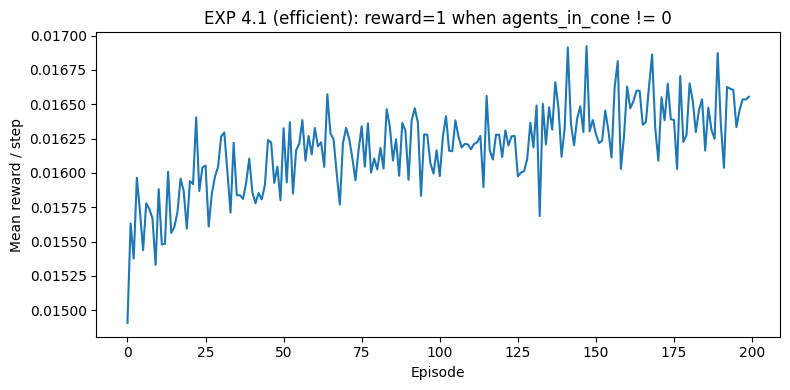

In [ ]:

plt.figure(figsize=(8, 4))
plt.plot(res_cone_eff[0].mean(0).mean(0) / time_ep)
plt.xlabel('Episode')
plt.ylabel('Mean reward / step')
plt.title('EXP 4.1 (efficient): reward=1 when agents_in_cone != 0')
plt.tight_layout()
plt.show()

Text(0, 0.5, 'P(continue)')

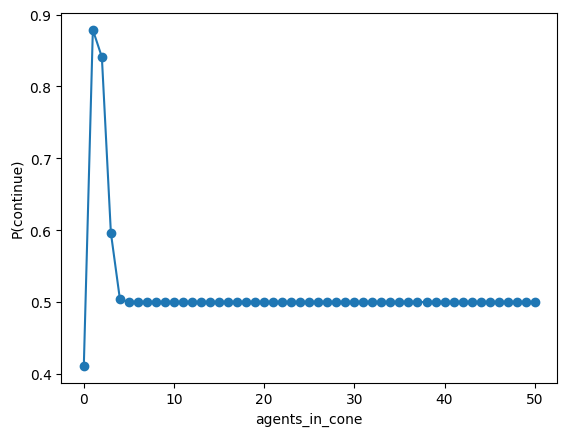

In [ ]:
hmats = res_cone_eff[1].reshape(20*50, 2, -1)
probs = hmats[:,0] / hmats.sum(-2)

plt.plot(probs.mean(0), '-o'   )
plt.xlabel('agents_in_cone')
plt.ylabel('P(continue)')

# EXP 5
> Merges EXP 3.1 (target-finding reward + counter) with visual-cone features from EXP 4.
>
> **State space**: `[counter, any_agent_in_cone (0/1), rewarded_agent_in_cone (0/1)]`
>
> - `counter`: clipped to `[0, max_counter-1]`, reset on reward
> - `any_agent_in_cone`: 1 if any agent is visible in the frontal cone, else 0
> - `rewarded_agent_in_cone`: 1 if any agent with `env.rewarded_agents == 1` is visible, else 0
>
> **Reward**: from `env.check_encounter()` (finding targets), same as EXP 3.1

In [ ]:
@njit
def training_exp5(episodes, time_ep, env, agents, max_counter):
    """
    EXP 5: Target-finding reward with 3D state = [counter, any_agent_in_cone, rewarded_agent_in_cone].

    Uses Foragers_efficient with lazy G updates.
    state_space should be np.array([max_counter, 2, 2]).
    """
    save_rewards = np.zeros((agents.num_agents, episodes))
    agents_rewarded = np.zeros(agents.num_agents, dtype=np.bool_)

    for ep in range(episodes):
        env.init_env()
        agents.agent_states = np.zeros_like(agents.agent_states)
        agents.reset_g()

        for t in range(time_ep):
            agents.increment_counters()

            # --- Build observations ---
            # 1) Counter (clipped)
            counters = np.minimum(agents.get_state().copy(), np.int64(max_counter - 1))

            # 2) Cone features
            _, agents_spot = env.agents_in_cone()
            # agents_spot is (num_agents, num_agents) with 1 if j is in i's cone

            # any_agent_in_cone: 1 if row sum > 0
            any_in_cone = np.zeros(agents.num_agents, dtype=np.float64)
            for i in range(agents.num_agents):
                if agents_spot[i].sum() > 0:
                    any_in_cone[i] = 1.0

            # rewarded_agent_in_cone: 1 if any agent with rewarded_agents==1 is in cone
            rewarded_in_cone = np.zeros(agents.num_agents, dtype=np.float64)
            for i in range(agents.num_agents):
                for j in range(agents.num_agents):
                    if agents_spot[i, j] == 1 and env.rewarded_agents[j] == 1:
                        rewarded_in_cone[i] = 1.0
                        break

            # observations shape: (num_agents, 3)
            observations = np.empty((agents.num_agents, 3), dtype=np.float64)
            observations[:, 0] = counters.astype(np.float64)
            observations[:, 1] = any_in_cone
            observations[:, 2] = rewarded_in_cone

            actions = agents.deliberate(observations)

            # Post-reward step: force turn + reset counter BEFORE act
            actions[agents_rewarded] = 1
            agents.agent_states[agents_rewarded] = 0

            agents.act(actions)

            # Environment step
            env.update_pos(actions == 1)
            env.check_bc()
            env.update_target_state()
            env.update_rewarded_agents()

            rewards = env.check_encounter()
            rewards[agents_rewarded] = 0  # suppress double reward

            save_rewards[:, ep] += rewards
            agents._learn_post_reward(rewards)

            agents_rewarded = rewards == 1

    return save_rewards, agents.h_matrix


@njit(parallel=True)
def run_exp5(episodes, time_ep, runs,
             # Environment props
             Nt=100,
             L=100,
             r=0.5,
             tau=5,
             tau_reward=1,
             num_agents=10,
             agent_step=1,
             visual_range=2.0,
             visual_angle=np.pi / 2,
             shared_depletion=True,
             # Agent props
             num_actions=2,
             state_space=np.array([50, 2, 2]),
             gamma_damping=0.00001,
             eta_glow_damping=0.1,
             initial_h_0=False,
             h_0=np.zeros((1, 2, 200)),
             g_update='s',
             policy_type='standard',
             beta_softmax=3,
             max_no_H_update=int(1e3),
             ):
    """
    Parallel launcher for EXP 5.
    state_space = np.array([max_counter, 2, 2])
    """
    save_h_matrix = np.zeros((runs, num_agents, num_actions, state_space.prod()))
    save_rewards = np.zeros((runs, num_agents, episodes))

    for n_run in prange(runs):
        agents = Foragers_efficient(
            num_agents, num_actions, state_space,
            gamma_damping, eta_glow_damping, policy_type, beta_softmax,
            initial_h_0, h_0, g_update, max_no_H_update,
        )
        env = CollectiveEnv(num_agents, Nt, L, r, tau, agent_step,
                            visual_range, visual_angle, shared_depletion, tau_reward)

        rews, mat = training_exp5(episodes, time_ep, env, agents, state_space[0])

        for t in range(episodes):
            save_rewards[n_run, :, t] = rews[:, t].mean()
        save_h_matrix[n_run] = mat

    return save_rewards, save_h_matrix

In [ ]:
num_agents = 20
max_counter = 50
runs = 5

Nt = 100; L = 100; r = 1; tau = 1; tau_reward = 3
gamma_damping = 0.00001
eta_glow_damping = 0.1

# State space: [counter, any_agent_in_cone (0/1), rewarded_agent_in_cone (0/1)]
state_space_exp5 = np.array([max_counter, 2, 2])

time_ep = 5000
episodes = 1000

res_exp5 = run_exp5(
    episodes=episodes,
    time_ep=time_ep,
    runs= runs * numba.get_num_threads(),
    num_agents=num_agents,
    Nt=Nt, L=L, r=r, tau=tau, tau_reward=tau_reward,
    state_space=state_space_exp5,
    gamma_damping=gamma_damping,
    eta_glow_damping=eta_glow_damping,
    shared_depletion=False,
)

[<matplotlib.lines.Line2D>]

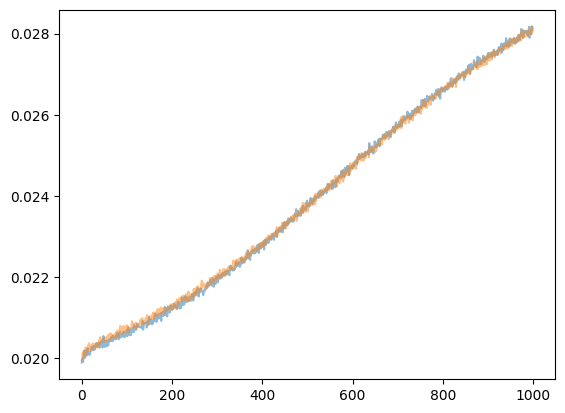

In [ ]:
folder_exp3 = "/home/gorka/github/rl_opts/nbs/lib_nbs/develop/results/exp_3"
rewards_exp3 = np.load(os.path.join(folder_exp3, f"save_rewards_tau{tau}_agents{num_agents}.npy"))
h_matrix_exp3 = np.load(os.path.join(folder_exp3, f"save_h_matrix_tau{tau}_agents{num_agents}.npy"))

plt.plot(rewards_exp3.mean(0).mean(0)[:episodes]/time_ep, label = f"{n_agents} agents", alpha = 0.5)

plt.plot(res_exp5[0].mean(0).mean(0)/time_ep, label = f"EXP 5", alpha = 0.5)


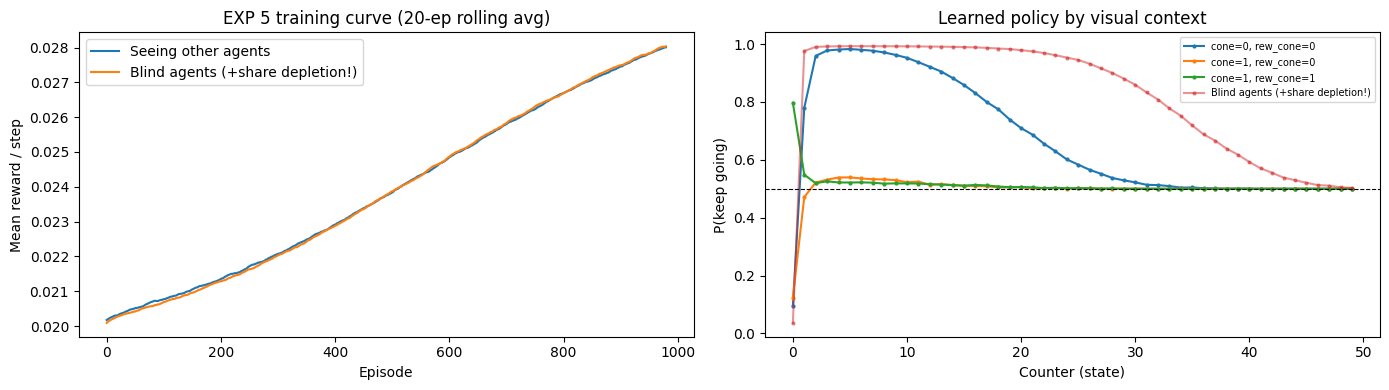

In [ ]:
fig5, axes5 = plt.subplots(1, 2, figsize=(14, 4))

# Training curve
_w5 = 20
_curve5 = res_exp5[0].mean(0).mean(0)  # mean over runs and agents
_roll5 = np.array([_curve5[i:i+_w5].mean() for i in range(len(_curve5) - _w5)])
axes5[0].plot(_roll5 / time_ep, label = f"Seeing other agents")
axes5[0].set_xlabel("Episode")
axes5[0].set_ylabel("Mean reward / step")
axes5[0].set_title(f"EXP 5 training curve ({_w5}-ep rolling avg)")

_curver3 = rewards_exp3.mean(0).mean(0)[:episodes]
_rollr3 = np.array([_curver3[i:i+_w5].mean() for i in range(len(_curver3) - _w5)])
axes5[0].plot(_rollr3 / time_ep, label="Blind agents (+share depletion!)")
axes5[0].legend()


# Learned policy: P(keep going | counter) for each (any_in_cone, rewarded_in_cone) combo
# Percept layout: counter * 4 + any_in_cone * 2 + rewarded_in_cone
hmats5 = res_exp5[1]  # (runs, num_agents, 2, max_counter*2*2)
hmats5_flat = hmats5.reshape(-1, 2, max_counter * 4)  # (runs*agents, 2, percepts)
p_keep = hmats5_flat[:, 0, :] / hmats5_flat.sum(1)

for cone_val in [0, 1]:
    for rew_val in [0, 1]:

        if cone_val == 0 and rew_val == 1:
            continue  # impossible state: can't see a rewarded agent if no agents are in the cone

        # idxs = np.arange(max_counter) * 4 + cone_val * 2 + rew_val
        obs = np.hstack((np.arange(max_counter).reshape(-1,1), cone_val*np.ones((max_counter, 1))))
        obs = np.hstack((obs, rew_val*np.ones((max_counter, 1))))
        idxs = agents.percept_preprocess(obs)

        label = f"cone={cone_val}, rew_cone={rew_val}"
        axes5[1].plot(p_keep[:, idxs].mean(0), '-o', ms=2, label=label)


hmats3 = h_matrix_exp3.reshape(-1, 2, h_matrix_exp3.shape[-1])  # (runs*agents, 2, percepts)
p_keep_exp3 = hmats3[:, 0, :] / hmats3.sum(1)
axes5[1].plot(p_keep_exp3.mean(0)[:max_counter], '-o', ms=2, label="Blind agents (+share depletion!)", alpha = 0.5)

axes5[1].axhline(0.5, color='k', lw=0.8, ls='--')
axes5[1].set_xlabel("Counter (state)")
axes5[1].set_ylabel("P(keep going)")
axes5[1].set_title("Learned policy by visual context")
axes5[1].legend(fontsize=7)

plt.tight_layout()
plt.show()

# EXP 6
> Comparing properly non/shared depletion and yes/no visual cone.

In [ ]:
from rl_opts.rl_framework.numba.agents import Foragers_efficient, run_collective

from rl_opts.rl_framework.numba.environments import CollectiveEnv

import numba

import os

import numpy as np

In [ ]:
num_agents = 50
max_counter = 50
runs = 5

Nt = 100; 
# We divide by 2 to allow better visibility between agents. The density stays the same
L = 50; r = 0.5
agent_step = 1
# Time delays
tau = 2; tau_reward = 3
# Visual cone
visual_range=2.0
visual_angle=np.pi / 2 # Note that this is from the center, so from +45 to -45

# Training parameters
gamma_damping = 0.00001
eta_glow_damping = 0.1
# State space: [counter, any_agent_in_cone (0/1), rewarded_agent_in_cone (0/1)]
state_space = np.array([max_counter, 2, 2])
agents = Foragers_efficient(num_agents, 2, state_space)

time_ep = 5000
episodes = 2000

out_dir = '/media/gorka/DATA/rl_opts_data/results_learning/collective/exp_6/'
os.makedirs(out_dir, exist_ok=True)

In [ ]:


for shared_depletion in [True, False]:
    for visual_activated in [True, False]:

        rews, mats = run_collective(episodes = episodes, time_ep = time_ep, 
                                    runs=runs * numba.get_num_threads(),
                                    # Environment props
                                    Nt=Nt,
                                    L=L,
                                    r=r,
                                    tau=tau,
                                    tau_reward=tau_reward,
                                    num_agents=num_agents,
                                    agent_step=agent_step,
                                    visual_range=visual_range,
                                    visual_angle=visual_angle,
                                    shared_depletion=shared_depletion,
                                    visual_activated = visual_activated,
                                    # Agent props
                                    num_actions=2,
                                    state_space=state_space,
                                    gamma_damping=gamma_damping,
                                    eta_glow_damping=eta_glow_damping,
                                    )
        

        rewards_path = os.path.join(out_dir, f"rewards_shared_{shared_depletion}_visual_{visual_activated}.npy.npy")
        h_matrix_path = os.path.join(out_dir, f"h_matrix_shared_{shared_depletion}_visual_{visual_activated}.npy.npy")

        np.save(rewards_path, rews)
        np.save(h_matrix_path, mats)
        

## Results

In [ ]:
folder_exp6 = '/media/gorka/DATA/rl_opts_data/results_learning/collective/exp_6/'

def _load_case(shared_depletion, visual_activated):

    rewards_path = os.path.join(
        folder_exp6,
        f"rewards_shared_{shared_depletion}_visual_{visual_activated}.npy.npy",
    )

    h_matrix_path = os.path.join(
        folder_exp6,
        f"h_matrix_shared_{shared_depletion}_visual_{visual_activated}.npy.npy",
    )

    rewards = np.load(rewards_path)
    h_matrix = np.load(h_matrix_path)

    return rewards, h_matrix

labels = {
    (True,  True):  "shared=True, visual=True",
    (True,  False): "shared=True, visual=False",
    (False, True):  "shared=False, visual=True",
    (False, False): "shared=False, visual=False",
}

### All together

<matplotlib.legend.Legend>

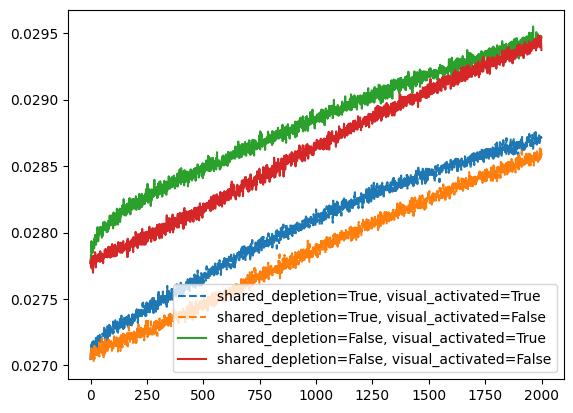

In [ ]:
for shared_depletion in [True, False]:
    for visual_activated in [True, False]:

        rewards_path = os.path.join(out_dir, f"rewards_shared_{shared_depletion}_visual_{visual_activated}.npy.npy")
        h_matrix_path = os.path.join(out_dir, f"h_matrix_shared_{shared_depletion}_visual_{visual_activated}.npy.npy")

        rews = np.load(rewards_path)
        mats = np.load(h_matrix_path)

        if shared_depletion:
            ls = '--'
        else:
            ls = '-'
        plt.plot(rews.mean(0).mean(0)/time_ep, 
                 label = f"shared_depletion={shared_depletion}, visual_activated={visual_activated}", ls = ls)

plt.legend()

### No visual cone

<matplotlib.legend.Legend>

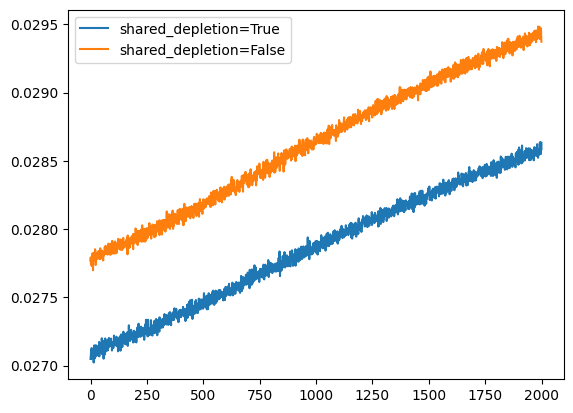

In [ ]:
visual_activated = False

for shared_depletion in [True, False]:

    rewards_path = os.path.join(out_dir, f"rewards_shared_{shared_depletion}_visual_{visual_activated}.npy.npy")
    h_matrix_path = os.path.join(out_dir, f"h_matrix_shared_{shared_depletion}_visual_{visual_activated}.npy.npy")

    rews = np.load(rewards_path)
    mats = np.load(h_matrix_path)

    plt.plot(rews.mean(0).mean(0)/time_ep, 
                label = f"shared_depletion={shared_depletion}", ls = ls)

plt.legend()

<matplotlib.legend.Legend>

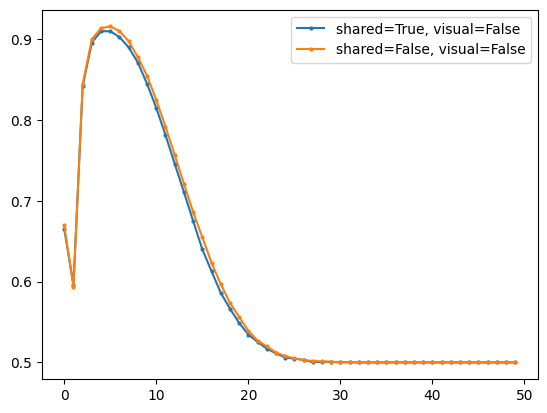

In [ ]:
# Load and compare EXP 6 outputs (saved by the previous cell)


cases = [ # shared_depletion, visual_activated
    (True,  False),
    (False, False),
]


for idx_case, case in enumerate(cases):

    _, hmat_case = _load_case(*case)
    hflat = hmat_case.reshape(-1, 2, hmat_case.shape[-1])
    p_keep = hflat[:, 0, :] / hflat.sum(1)


    # No visual cone
    cone_val = 0; rew_val = 0
    obs = np.hstack((np.arange(max_counter).reshape(-1,1), cone_val*np.ones((max_counter, 1))))
    obs = np.hstack((obs, rew_val*np.ones((max_counter, 1))))
    idxs = agents.percept_preprocess(obs)

    plt.plot(p_keep[:, idxs].mean(0), '-o', ms=2, label=labels[case])
    
plt.legend()



### Visual cone

#### Comparison between share depletion modes

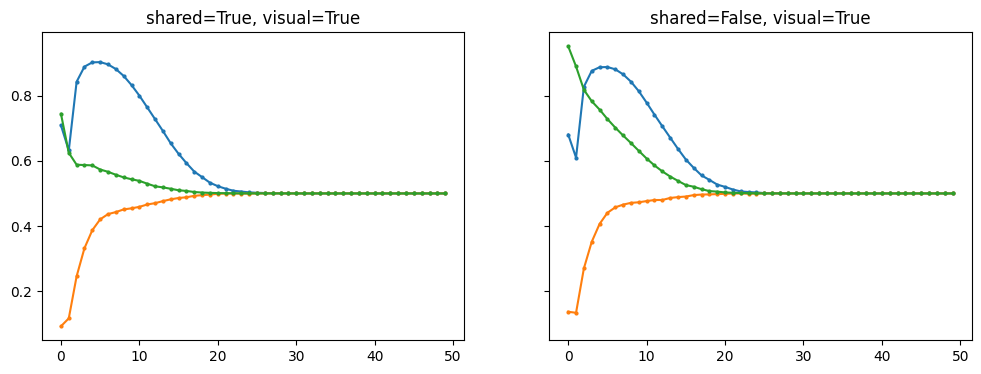

In [ ]:
# Load and compare EXP 6 outputs (saved by the previous cell)


cases = [ # shared_depletion, visual_activated
    (True,  True),
    (False, True)
]

fig_h, axes_h = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for idx_case, (case, ax) in enumerate(zip(cases, axes_h)):

    _, hmat_case = _load_case(*case)
    hflat = hmat_case.reshape(-1, 2, hmat_case.shape[-1])
    p_keep = hflat[:, 0, :] / hflat.sum(1)


    for cone_val in [0, 1]:
        for rew_val in [0, 1]:

            if cone_val == 0 and rew_val == 1:
                continue  # impossible state: can't see a rewarded agent if no agents are in the cone

            # idxs = np.arange(max_counter) * 4 + cone_val * 2 + rew_val
            obs = np.hstack((np.arange(max_counter).reshape(-1,1), cone_val*np.ones((max_counter, 1))))
            obs = np.hstack((obs, rew_val*np.ones((max_counter, 1))))
            idxs = agents.percept_preprocess(obs)

            label = f"cone={cone_val}, rew_cone={rew_val}"
            ax.plot(p_keep[:, idxs].mean(0), '-o', ms=2, label=label)
    
    ax.set_title(labels[case])




#### Comparing no agents in front vs no visual cone

<matplotlib.legend.Legend>

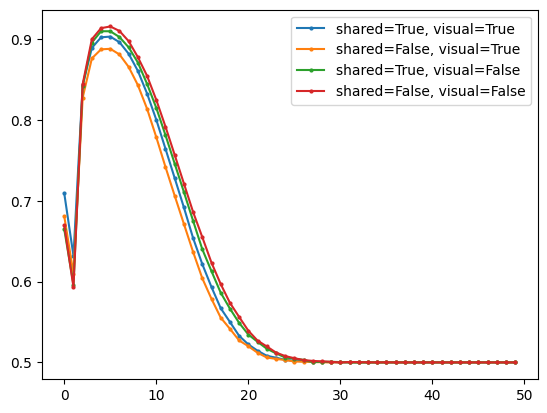

In [ ]:
# Load and compare EXP 6 outputs (saved by the previous cell)


cases = [ # shared_depletion, visual_activated
    (True,  True),
    (False, True),
    (True, False),
    (False, False),
]


for idx_case, case in enumerate(cases):

    _, hmat_case = _load_case(*case)
    hflat = hmat_case.reshape(-1, 2, hmat_case.shape[-1])
    p_keep = hflat[:, 0, :] / hflat.sum(1)


    cone_val = 0; rew_val = 0
    obs = np.hstack((np.arange(max_counter).reshape(-1,1), cone_val*np.ones((max_counter, 1))))
    obs = np.hstack((obs, rew_val*np.ones((max_counter, 1))))
    idxs = agents.percept_preprocess(obs)

    label = f"cone={cone_val}, rew_cone={rew_val}"
    plt.plot(p_keep[:, idxs].mean(0), '-o', ms=2, label=labels[case])

plt.legend()




#### Understanding spatially the problem: how big cone? how many agents?

In [ ]:
num_agents = 30
Nt = 20; 
# We divide by 2 to allow better visibility between agents. The density stays the same
L = 25; r = 0.5
agent_step = 1
# Time delays
tau = 2; tau_reward = 3
# Visual cone
visual_range=3.0
visual_angle=np.pi / 4

positions = np.random.rand(num_agents, 2) * L
directions = np.random.rand(num_agents) * 2 * np.pi


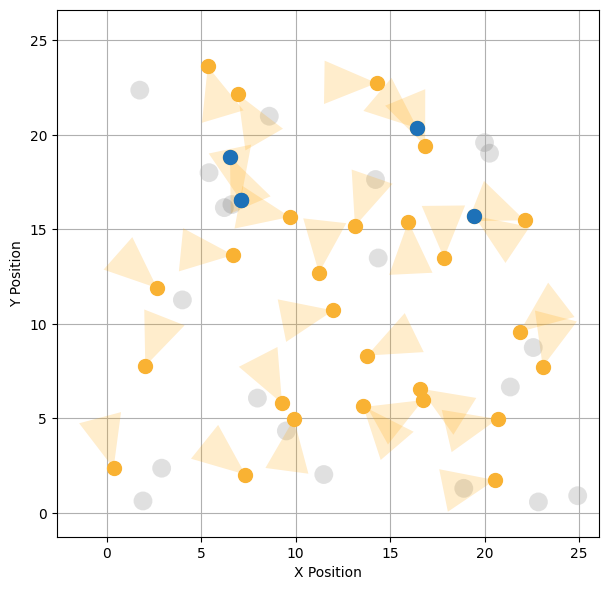

In [ ]:
theta = visual_angle
k = visual_range

num_agents = positions.shape[0]

# Create the plot
plt.figure(figsize=(7, 7))
plt.scatter(positions[:, 0], positions[:, 1], label="Agents", color="blue", zorder=5)

for i in range(num_agents):
    agent_pos = positions[i]
    agent_dir = directions[i]

    # Highlight the current agent
    plt.scatter(agent_pos[0], agent_pos[1], color="#f9b233ff", zorder=6, s = 100)

    # Draw the cone for the current agent
    cone_left = agent_dir - theta / 2
    cone_right = agent_dir + theta / 2
    cone_x = [agent_pos[0], agent_pos[0] + k * np.cos(cone_left), agent_pos[0] + k * np.cos(cone_right)]
    cone_y = [agent_pos[1], agent_pos[1] + k * np.sin(cone_left), agent_pos[1] + k * np.sin(cone_right)]
    plt.fill(cone_x, cone_y, color="orange", alpha=0.2, zorder=4, lw = 0)

    # Check which agents are in the cone
    for j in range(num_agents):
        if i == j:
            continue

        # Compute the relative position
        relative_pos = positions[j] - agent_pos
        distance = np.sqrt(relative_pos[0]**2 + relative_pos[1]**2)

        if distance <= k:
            angle = np.arctan2(relative_pos[1], relative_pos[0])
            angle_diff = np.abs((angle - agent_dir + np.pi) % (2 * np.pi) - np.pi)

            if angle_diff <= theta / 2:
                # Highlight agents in the cone
                plt.scatter(positions[j, 0], positions[j, 1], color="#1d71b8ff", zorder=7, edgecolors = "#1d71b8ff", s = 100)

# Randomly distribute Nt traps in the environment and draw each as a true radius-r circle
trap_positions = np.random.rand(Nt, 2) * L

ax = plt.gca()
for t in range(Nt):
    trap = plt.Circle(
        (trap_positions[t, 0], trap_positions[t, 1]),
        r,                      # radius in data units
        facecolor="black",
        edgecolor="w",
        alpha=0.12,
        linewidth=0.6,
        zorder=1,
        label="Traps" if t == 0 else None
    )
    ax.add_patch(trap)

# Set plot limits and labels
plt.xlim(positions[:, 0].min() - k, positions[:, 0].max() + k)
plt.ylim(positions[:, 1].min() - k, positions[:, 1].max() + k)
plt.gca().set_aspect('equal', adjustable='box')
# plt.legend(["Agents", "Selected Agent", "In Cone"])

plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.grid()
plt.show()

# EXP 7
> Parameter sweep for taus and range

In [ ]:
from rl_opts.rl_framework.numba.agents import Foragers_efficient, run_collective
from rl_opts.rl_framework.numba.environments import CollectiveEnv
import numba
import os
import numpy as np

num_agents = 50
max_counter = 50
runs = 5

Nt = 100; 
# We divide by 2 to allow better visibility between agents. The density stays the same
L = 50; r = 0.5
agent_step = 1
# Time delays
taus = [2, 3, 4]; 
taus_reward = [3, 4, 5]
# Visual cone
visual_activated = True
visual_ranges = [2.0, 3.0, 4.0]
visual_angle=np.pi / 2 # Note that this is from the center, so from +45 to -45

# Training parameters
gamma_damping = 0.00001
eta_glow_damping = 0.1
# State space: [counter, any_agent_in_cone (0/1), rewarded_agent_in_cone (0/1)]
state_space = np.array([max_counter, 2, 2])
agents = Foragers_efficient(num_agents, 2, state_space)

time_ep = 5000
episodes = 2000


out_dir = "/media/gorka/DATA/rl_opts_data/results_learning/collective/exp_7"
os.makedirs(out_dir, exist_ok=True)




In [ ]:
test_save = os.path.join(out_dir, 'test_save.npy')
np.save(test_save, np.arange(10))

for tau in taus:
    for tau_reward in taus_reward:
        for visual_range in visual_ranges:
            for shared_depletion in [True, False]:

                if tau == taus[0] and tau_reward == taus_reward[0] and visual_range == visual_ranges[0]:
                    continue  # already ran this case in EXP 6
                
                file_name = f"_shared_{shared_depletion}_tau_{tau}_tauR_{tau_reward}_vr_{visual_range}.npy"
                rewards_path = os.path.join(out_dir, 
                                            "rewards"+file_name)
                h_matrix_path = os.path.join(out_dir, 
                                             f"h_matrix"+file_name)

                if os.path.exists(rewards_path) and os.path.exists(h_matrix_path):
                    print(f"Skipping existing case: {file_name}")
                    continue

                print(f"Running case: {file_name}")

                # rews, mats = run_collective(episodes = episodes, time_ep = time_ep, 
                #                             runs=runs * numba.get_num_threads(),
                #                             # Environment props
                #                             Nt=Nt,
                #                             L=L,
                #                             r=r,
                #                             tau=tau,
                #                             tau_reward=tau_reward,
                #                             num_agents=num_agents,
                #                             agent_step=agent_step,
                #                             visual_range=visual_range,
                #                             visual_angle=visual_angle,
                #                             shared_depletion=shared_depletion,
                #                             visual_activated = visual_activated,
                #                             # Agent props
                #                             num_actions=2,
                #                             state_space=state_space,
                #                             gamma_damping=gamma_damping,
                #                             eta_glow_damping=eta_glow_damping,
                #                             )
                
                

                # np.save(rewards_path, rews)
                # np.save(h_matrix_path, mats)
        


Skipping existing case: _shared_True_tau_2_tauR_3_vr_3.0.npy
Skipping existing case: _shared_False_tau_2_tauR_3_vr_3.0.npy
Skipping existing case: _shared_True_tau_2_tauR_3_vr_4.0.npy
Skipping existing case: _shared_False_tau_2_tauR_3_vr_4.0.npy
Skipping existing case: _shared_True_tau_2_tauR_4_vr_2.0.npy
Skipping existing case: _shared_False_tau_2_tauR_4_vr_2.0.npy
Skipping existing case: _shared_True_tau_2_tauR_4_vr_3.0.npy
Skipping existing case: _shared_False_tau_2_tauR_4_vr_3.0.npy
Skipping existing case: _shared_True_tau_2_tauR_4_vr_4.0.npy
Skipping existing case: _shared_False_tau_2_tauR_4_vr_4.0.npy
Skipping existing case: _shared_True_tau_2_tauR_5_vr_2.0.npy
Skipping existing case: _shared_False_tau_2_tauR_5_vr_2.0.npy
Skipping existing case: _shared_True_tau_2_tauR_5_vr_3.0.npy
Skipping existing case: _shared_False_tau_2_tauR_5_vr_3.0.npy
Skipping existing case: _shared_True_tau_2_tauR_5_vr_4.0.npy
Skipping existing case: _shared_False_tau_2_tauR_5_vr_4.0.npy
Skipping existin

In [ ]:
for tau in taus:
    for tau_reward in taus_reward:
        for visual_range in visual_ranges:
            for shared_depletion in [True, False]:

                skip_cases = {
                            (2, 3, 2.0, True),
                            (2, 3, 2.0, False),
                            (2, 3, 3.0, True),
                            (2, 3, 3.0, False),
                            (2, 3, 4.0, True),
                            (2, 3, 4.0, False),
                            (2, 4, 2.0, True),
                            (2, 4, 2.0, False),
                            (2, 4, 3.0, True),
                            (2, 4, 3.0, False),
                            (2, 4, 4.0, True),
                            (2, 4, 4.0, False),
                        }
                
                case = (tau, tau_reward, visual_range, shared_depletion)
                if case not in skip_cases:
                    continue

                
                    
                file_name = f"_shared_{shared_depletion}_tau_{tau}_tauR_{tau_reward}_vr_{visual_range}.npy"
                rewards_path = os.path.join(out_dir, 
                                        "rewards"+file_name)
                rews = np.load(rewards_path)

## Results

### Effect of the visual range
> Fixed $\tau$ and $\tau_R$

<matplotlib.legend.Legend>

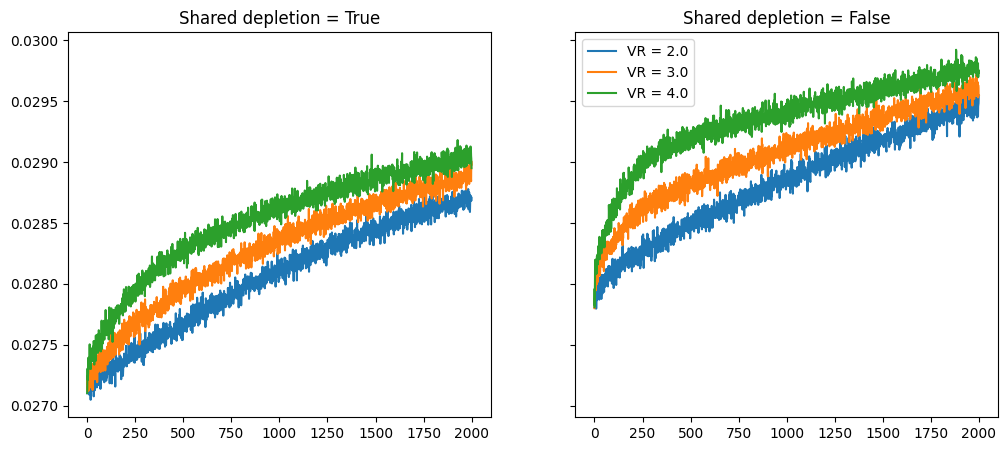

In [ ]:
tau = taus[0]
tau_reward = taus_reward[0]

fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for visual_range in visual_ranges:
    for idx_share, shared_depletion in enumerate([True, False]):

        file_name = f"_shared_{shared_depletion}_tau_{tau}_tauR_{tau_reward}_vr_{visual_range}.npy"
        rewards_path = os.path.join(out_dir, 
                                    "rewards"+file_name)
        # h_matrix_path = os.path.join(out_dir, 
        #                              f"h_matrix"+file_name)

        rews = np.load(rewards_path)
        # mats = np.load(h_matrix_path)

        ax[idx_share].plot(rews[:96].mean(0).mean(0)/time_ep, 
                 label = f"VR = {visual_range}")
        
        ax[idx_share].set_title(f"Shared depletion = {shared_depletion}")
ax[1].legend()

<matplotlib.legend.Legend>

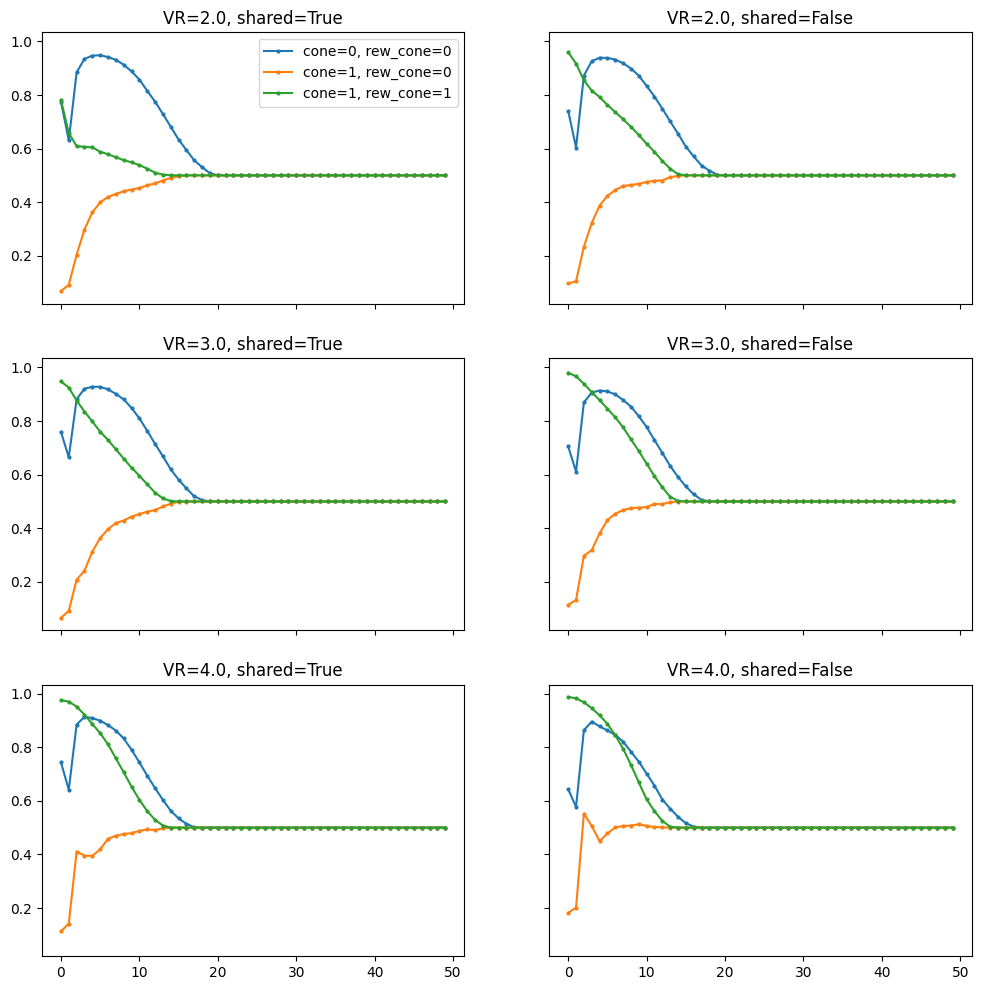

In [ ]:
fig_h, axs = plt.subplots(len(visual_ranges), 2, figsize=(12, len(visual_ranges)*4), sharey=True, sharex=True)

for idx_vr, visual_range in enumerate(visual_ranges):
    for idx_share, shared_depletion in enumerate([True, False]):

        file_name = f"_shared_{shared_depletion}_tau_{tau}_tauR_{tau_reward}_vr_{visual_range}.npy"
        h_matrix_path = os.path.join(out_dir, 
                                     f"h_matrix"+file_name)
        mats = np.load(h_matrix_path)
        hflat = mats.reshape(-1, 2, mats.shape[-1])
        p_keep = hflat[:, 0, :] / hflat.sum(1)


        for cone_val in [0, 1]:
            for rew_val in [0, 1]:

                if cone_val == 0 and rew_val == 1:
                    continue  # impossible state: can't see a rewarded agent if no agents are in the cone

                obs = np.hstack((np.arange(max_counter).reshape(-1,1), cone_val*np.ones((max_counter, 1))))
                obs = np.hstack((obs, rew_val*np.ones((max_counter, 1))))
                idxs = agents.percept_preprocess(obs)

                label = f"cone={cone_val}, rew_cone={rew_val}"
                axs[idx_vr, idx_share].plot(np.median(p_keep[:, idxs], axis=0), '-o', ms=2, label=label)                
                axs[idx_vr, idx_share].set_title(f"VR={visual_range}, shared={shared_depletion}")
    
axs[0, 0].legend()



Comparing different visual cases for values

<matplotlib.legend.Legend>

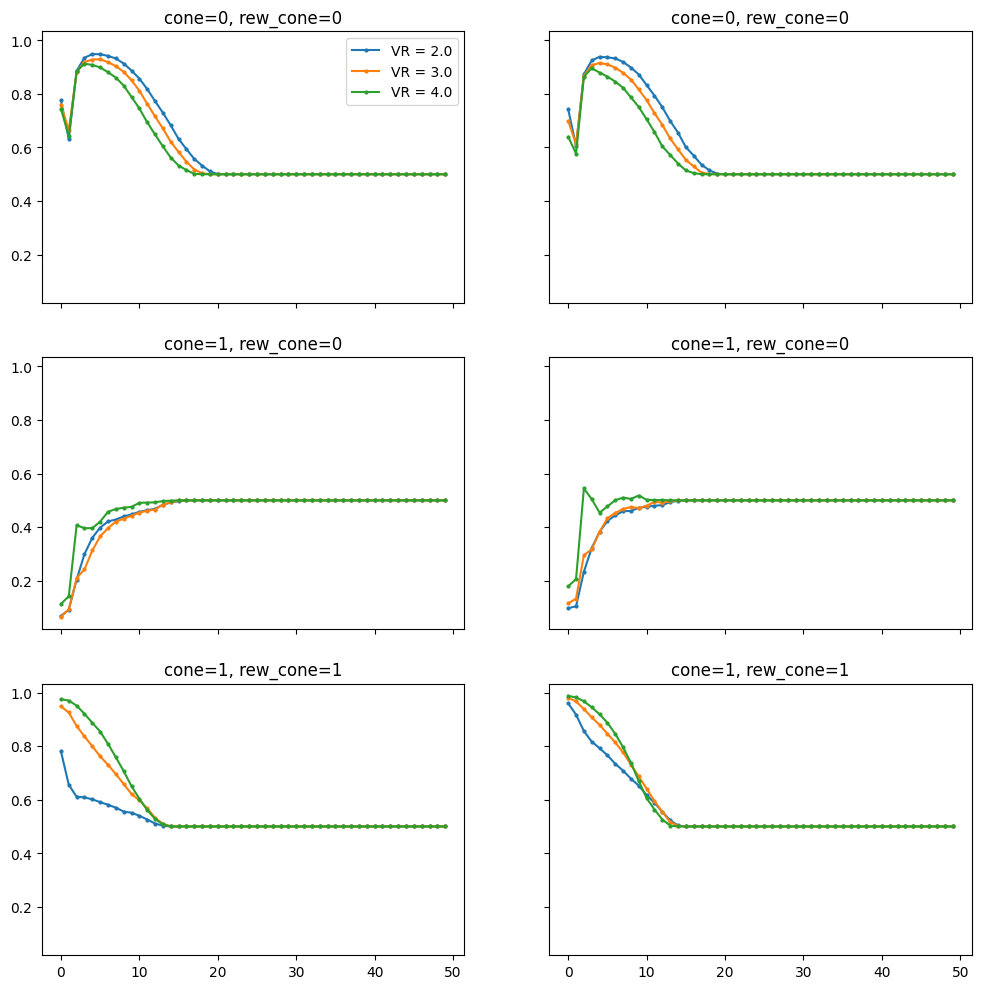

In [ ]:
fig_h, axs = plt.subplots(len(visual_ranges), 2, figsize=(12, len(visual_ranges)*4), sharey=True, sharex=True)

for idx_vr, visual_range in enumerate(visual_ranges):
    for idx_share, shared_depletion in enumerate([True, False]):

        file_name = f"_shared_{shared_depletion}_tau_{tau}_tauR_{tau_reward}_vr_{visual_range}.npy"
        h_matrix_path = os.path.join(out_dir, 
                                     f"h_matrix"+file_name)
        mats = np.load(h_matrix_path)
        hflat = mats[:144].reshape(-1, 2, mats.shape[-1])
        p_keep = hflat[:, 0, :] / hflat.sum(1)


        for cone_val in [0, 1]:
            for rew_val in [0, 1]:

                if cone_val == 0 and rew_val == 1:
                    continue  # impossible state: can't see a rewarded agent if no agents are in the cone

                obs = np.hstack((np.arange(max_counter).reshape(-1,1), cone_val*np.ones((max_counter, 1))))
                obs = np.hstack((obs, rew_val*np.ones((max_counter, 1))))
                idxs = agents.percept_preprocess(obs)

                title = f"cone={cone_val}, rew_cone={rew_val}"
                axs[cone_val+rew_val, idx_share].set_title(title)

                axs[cone_val+rew_val, idx_share].plot(np.median(p_keep[:, idxs], axis=0), '-o', ms=2, label=f'VR = {visual_range}') 
    
axs[0, 0].legend()



## EXP_7.1 Effect of the agents' reward decay
> Fixed $\tau$ and $VR$, we check $\tau_R$

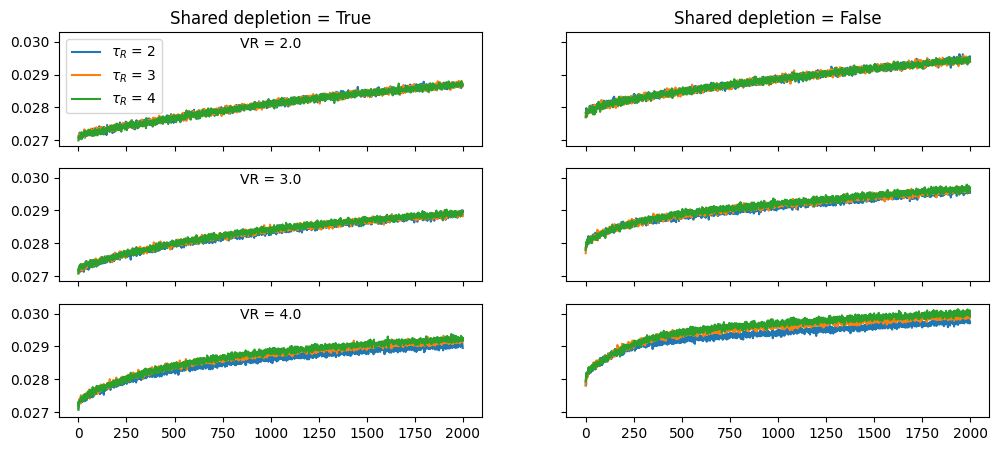

In [ ]:
out_dir = "/media/gorka/DATA/rl_opts_data/results_learning/collective/exp_7"
visual_ranges = [2.0, 3.0, 4.0]
taus = [2, 3, 4]; 
taus_reward = [3, 4, 5]
visual_ranges = [2.0, 3.0, 4.0]

tau = taus[0]

fig, ax = plt.subplots(3, 2, figsize=(12, 5), sharey=True, sharex = True)

for idx_vr, visual_range in enumerate(visual_ranges):
    for tau_reward in taus_reward:
        for idx_share, shared_depletion in enumerate([True, False]):

            file_name = f"_shared_{shared_depletion}_tau_{tau}_tauR_{tau_reward}_vr_{visual_range}.npy"
            rewards_path = os.path.join(out_dir, 
                                        "rewards"+file_name)
            # h_matrix_path = os.path.join(out_dir, 
            #                              f"h_matrix"+file_name)

            rews = np.load(rewards_path)
            # mats = np.load(h_matrix_path)

            ax[idx_vr, idx_share].plot(rews[:96].mean(0).mean(0)/time_ep, 
                    label = fr"$\tau_R$ = {tau_reward-1}") # Because of error in env, where tau_reward had a == instead of >
            
            if idx_vr==0:
                ax[idx_vr, idx_share].set_title(f"Shared depletion = {shared_depletion}")

    ax[idx_vr, 0].text(0.5, 0.9, f"VR = {visual_range}", transform=ax[idx_vr, 0].transAxes, ha='center', va='center')
    ax[0,0].legend()

The previous is quite unexpect. We launch now shorter training with $\tau$ and $VR$ at initial value and longer $\tau_R$ until we see a decay?

In [ ]:
from rl_opts.rl_framework.numba.agents import Foragers_efficient, run_collective
from rl_opts.rl_framework.numba.environments import CollectiveEnv
import numba
import os
import numpy as np

# Change for this run:
taus_reward = np.arange(2, 12, 1)
visual_range = 6

num_agents = 50
max_counter = 50
runs = 1

Nt = 100; 
# We divide by 2 to allow better visibility between agents. The density stays the same
L = 50; r = 0.5
agent_step = 1
# Time delays
taus = [2, 3, 4]; 

# Visual cone
visual_activated = True

visual_angle=np.pi / 2 # Note that this is from the center, so from +45 to -45

# Training parameters
gamma_damping = 0.00001
eta_glow_damping = 0.1
# State space: [counter, any_agent_in_cone (0/1), rewarded_agent_in_cone (0/1)]
state_space = np.array([max_counter, 2, 2])
agents = Foragers_efficient(num_agents, 2, state_space)

time_ep = 5000
episodes = 200


out_dir = "/media/gorka/DATA/rl_opts_data/results_learning/collective/exp_7_1"
os.makedirs(out_dir, exist_ok=True)


tau = taus[0]
shared_depletion = False
    
for tau_reward in taus_reward:

    rews, mats = run_collective(episodes = episodes, time_ep = time_ep, 
                                runs= runs * numba.get_num_threads(),
                                # Environment props
                                Nt=Nt,
                                L=L,
                                r=r,
                                tau=tau,
                                tau_reward=tau_reward,
                                num_agents=num_agents,
                                agent_step=agent_step,
                                visual_range=visual_range,
                                visual_angle=visual_angle,
                                shared_depletion=shared_depletion,
                                visual_activated = visual_activated,
                                # Agent props
                                num_actions=2,
                                state_space=state_space,
                                gamma_damping=gamma_damping,
                                eta_glow_damping=eta_glow_damping,
                                )
    
    file_name = f"_shared_{shared_depletion}_tau_{tau}_tauR_{tau_reward}_vr_{visual_range}.npy"
    rewards_path = os.path.join(out_dir, 
                                "rewards"+file_name)
    h_matrix_path = os.path.join(out_dir, 
                                    f"h_matrix"+file_name)

    np.save(rewards_path, rews)
    np.save(h_matrix_path, mats)
        


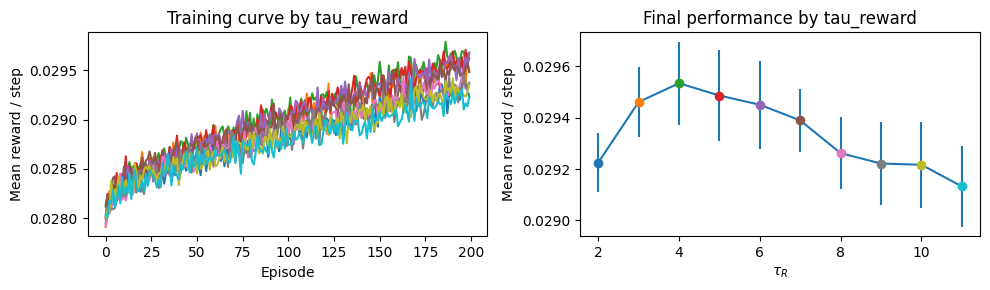

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3), tight_layout=True)

out_dir = "/media/gorka/DATA/rl_opts_data/results_learning/collective/exp_7_1"
taus_reward = np.arange(2, 12, 1)
visual_range = 6
tau = 2

final_rewards = np.zeros((len(taus_reward), runs * numba.get_num_threads()))
for idx_tau_reward, tau_reward in enumerate(taus_reward):

        file_name = f"_shared_{shared_depletion}_tau_{tau}_tauR_{tau_reward}_vr_{visual_range}.npy"
        rewards_path = os.path.join(out_dir, 
                                    "rewards"+file_name)
        # h_matrix_path = os.path.join(out_dir, 
        #                              f"h_matrix"+file_name)

        rews = np.load(rewards_path)
            # mats = np.load(h_matrix_path)

        ax[0].plot(rews.mean(0).mean(0)/time_ep, 
                label = fr"$\tau_R$ = {tau_reward-1}") # Because of error in env, where tau_reward had a == instead of >
        
        final_rewards[idx_tau_reward] = rews.mean(1)[:, -final_rewards.shape[-1]:].mean(-1)/time_ep

        ax[1].scatter(taus_reward[idx_tau_reward], final_rewards[idx_tau_reward].mean(), zorder = 10)

ax[1].errorbar(taus_reward, final_rewards.mean(1), yerr = final_rewards.std(1))
plt.setp(ax[0], xlabel = "Episode", ylabel = "Mean reward / step", title = "Training curve by tau_reward")
plt.setp(ax[1], xlabel = r"$\tau_R$", ylabel = "Mean reward / step", title = "Final performance by tau_reward");

## EXP_7.2 Effect of number of agents

In [ ]:
from rl_opts.rl_framework.numba.agents import Foragers_efficient, run_collective
from rl_opts.rl_framework.numba.environments import CollectiveEnv
import numba
import os
import numpy as np

# Change for this run:
nums_agents = np.arange(10, 80, 10)
tau = 3
tau_reward = 3
visual_range = 4

max_counter = 50
runs = 1

Nt = 100; 
L = 50; r = 0.5
agent_step = 1


# Visual cone
visual_activated = True
visual_angle=np.pi / 2 # Note that this is from the center, so from +45 to -45

# Training parameters
gamma_damping = 0.00001
eta_glow_damping = 0.1
# State space: [counter, any_agent_in_cone (0/1), rewarded_agent_in_cone (0/1)]
state_space = np.array([max_counter, 2, 2])


time_ep = 5000
episodes = 200


out_dir = "/media/gorka/DATA/rl_opts_data/results_learning/collective/exp_7_2"
os.makedirs(out_dir, exist_ok=True)

    
for num_agents in nums_agents:
    for shared_depletion in [True, False]:

        rews, mats = run_collective(episodes = episodes, time_ep = time_ep, 
                                    runs= runs * numba.get_num_threads(),
                                    # Environment props
                                    Nt=Nt,
                                    L=L,
                                    r=r,
                                    tau=tau,
                                    tau_reward=tau_reward,
                                    num_agents=num_agents,
                                    agent_step=agent_step,
                                    visual_range=visual_range,
                                    visual_angle=visual_angle,
                                    shared_depletion=shared_depletion,
                                    visual_activated = visual_activated,
                                    # Agent props
                                    num_actions=2,
                                    state_space=state_space,
                                    gamma_damping=gamma_damping,
                                    eta_glow_damping=eta_glow_damping,
                                    )
        
        file_name = f"_shared_{shared_depletion}_num_agents_{num_agents}.npy"
        rewards_path = os.path.join(out_dir, 
                                    "rewards"+file_name)
        h_matrix_path = os.path.join(out_dir, 
                                        f"h_matrix"+file_name)

        np.save(rewards_path, rews)
        np.save(h_matrix_path, mats)
        


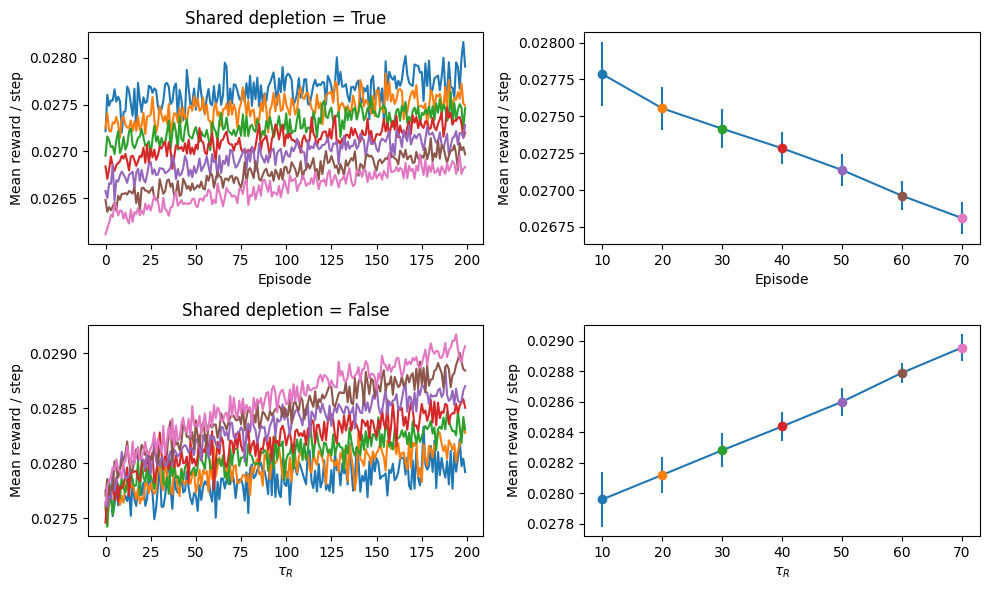

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(10, 6), tight_layout=True)

out_dir = "/media/gorka/DATA/rl_opts_data/results_learning/collective/exp_7_2"
taus_reward = np.arange(2, 12, 1)
visual_range = 6
tau = 2


for idx_s, shared_depletion in enumerate([True, False]):
        final_rewards = np.zeros((len(nums_agents), runs * numba.get_num_threads()))

        for idx_n, num_agents in enumerate(nums_agents):

                file_name = f"_shared_{shared_depletion}_num_agents_{num_agents}.npy"
                rewards_path = os.path.join(out_dir, 
                                        "rewards"+file_name)
                rews = np.load(rewards_path)

                ax[idx_s, 0].plot(rews.mean(0).mean(0)/time_ep, 
                        label = fr"$\tau_R$ = {tau_reward-1}") # Because of error in env, where tau_reward had a == instead of >
                
                final_rewards[idx_n] = rews.mean(1)[:, -final_rewards.shape[-1]:].mean(-1)/time_ep

                ax[idx_s, 1].scatter(nums_agents[idx_n], final_rewards[idx_n].mean(), zorder = 10)

        ax[idx_s, 1].errorbar(nums_agents, final_rewards.mean(1), yerr = final_rewards.std(1))
        ax[idx_s, 0].set_title(f"Shared depletion = {shared_depletion}")
        
plt.setp(ax[0, :], xlabel = "Episode", ylabel = "Mean reward / step")
plt.setp(ax[1, :], xlabel = r"$\tau_R$", ylabel = "Mean reward / step");

In [ ]:
agents = Foragers_efficient(num_agents, 2, state_space)

<matplotlib.legend.Legend>

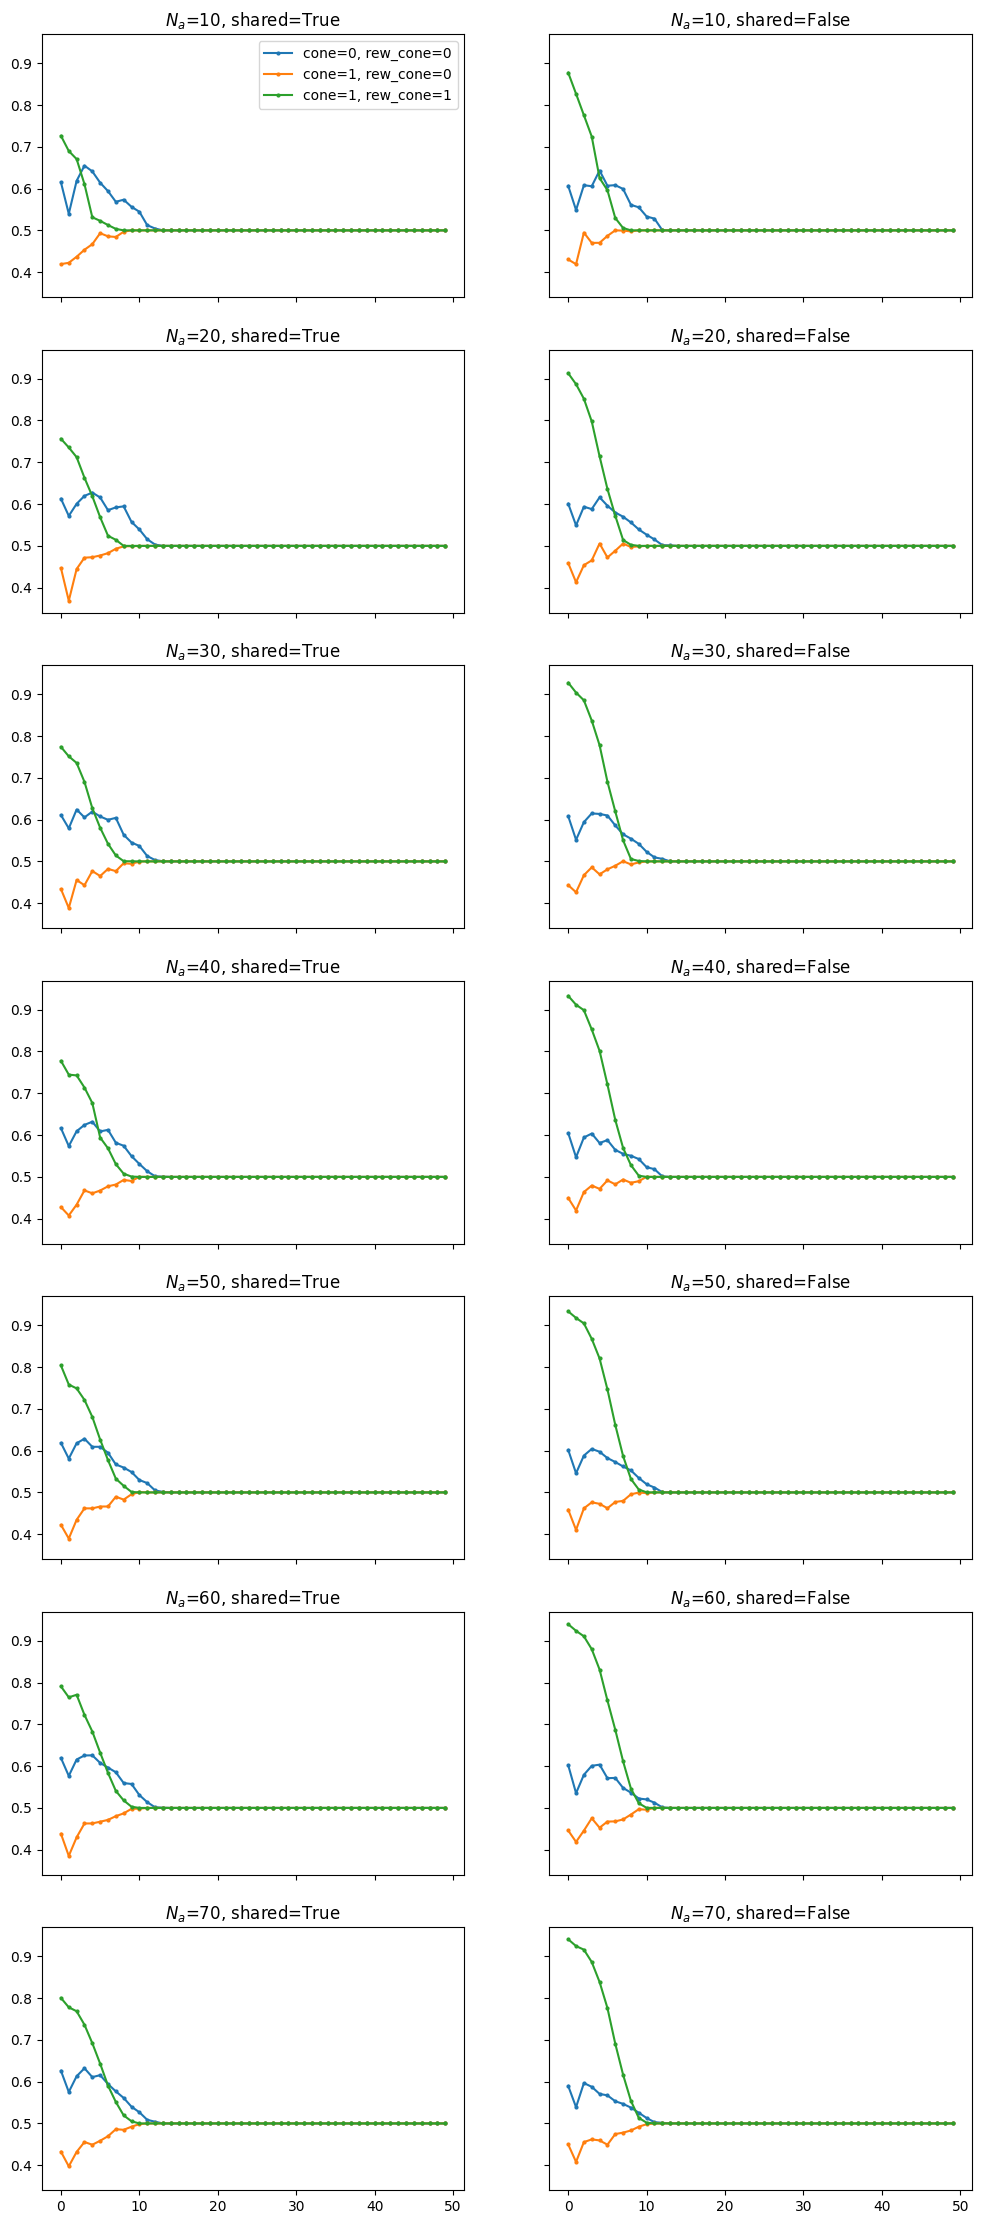

In [ ]:
fig_h, axs = plt.subplots(len(nums_agents), 2, figsize=(12, len(nums_agents)*4), sharey=True, sharex=True)

for idx_vr, num_agents in enumerate(nums_agents):
    for idx_share, shared_depletion in enumerate([True, False]):

        file_name = f"_shared_{shared_depletion}_num_agents_{num_agents}.npy"
        h_matrix_path = os.path.join(out_dir, 
                                     f"h_matrix"+file_name)
        mats = np.load(h_matrix_path)
        hflat = mats.reshape(-1, 2, mats.shape[-1])
        p_keep = hflat[:, 0, :] / hflat.sum(1)


        for cone_val in [0, 1]:
            for rew_val in [0, 1]:

                if cone_val == 0 and rew_val == 1:
                    continue  # impossible state: can't see a rewarded agent if no agents are in the cone

                obs = np.hstack((np.arange(max_counter).reshape(-1,1), cone_val*np.ones((max_counter, 1))))
                obs = np.hstack((obs, rew_val*np.ones((max_counter, 1))))
                idxs = agents.percept_preprocess(obs)

                label = f"cone={cone_val}, rew_cone={rew_val}"
                axs[idx_vr, idx_share].plot(np.median(p_keep[:, idxs], axis=0), '-o', ms=2, label=label)                
                axs[idx_vr, idx_share].set_title(fr"$N_a$={num_agents}, shared={shared_depletion}")
    
axs[0, 0].legend()



<matplotlib.legend.Legend>

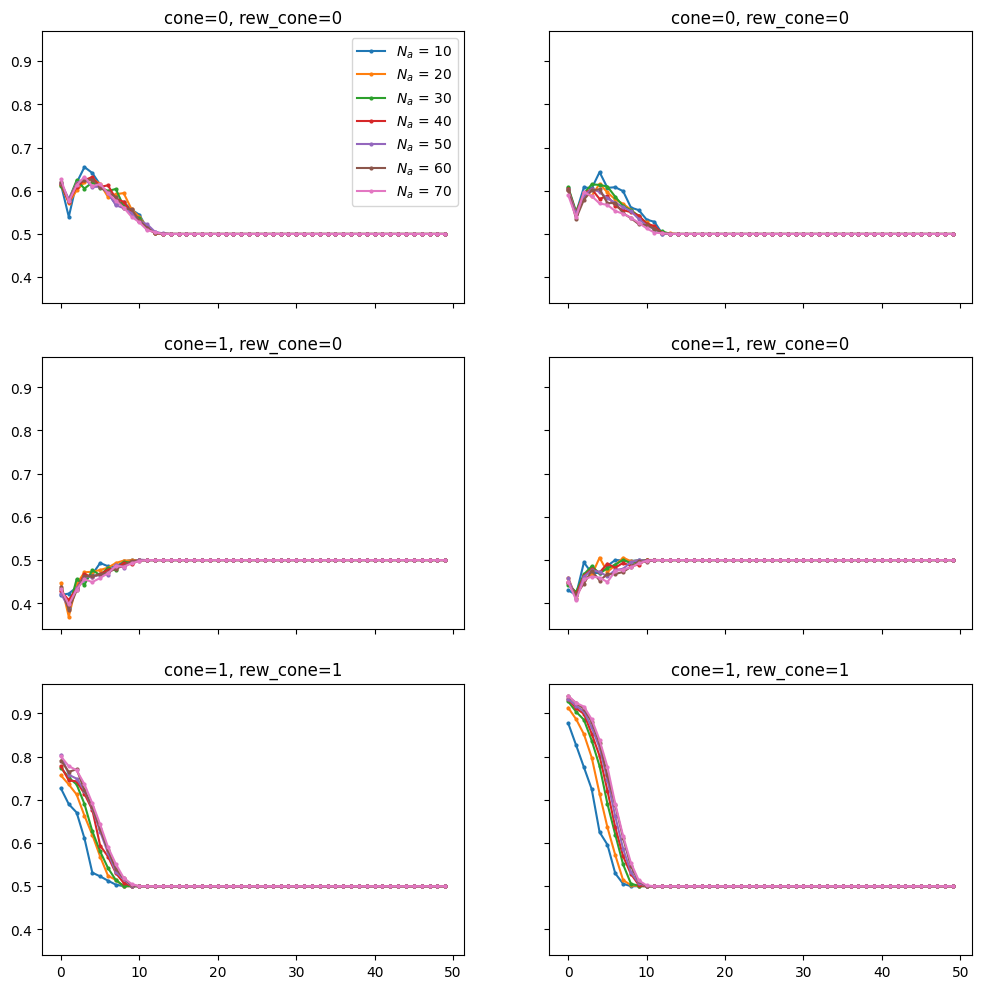

In [ ]:
fig_h, axs = plt.subplots(3, 2, figsize=(12, 3*4), sharey=True, sharex=True)

for idx_vr, num_agents in enumerate(nums_agents):
    for idx_share, shared_depletion in enumerate([True, False]):

        file_name = f"_shared_{shared_depletion}_num_agents_{num_agents}.npy"
        h_matrix_path = os.path.join(out_dir, 
                                     f"h_matrix"+file_name)
        mats = np.load(h_matrix_path)
        hflat = mats[:144].reshape(-1, 2, mats.shape[-1])
        p_keep = hflat[:, 0, :] / hflat.sum(1)


        for cone_val in [0, 1]:
            for rew_val in [0, 1]:

                if cone_val == 0 and rew_val == 1:
                    continue  # impossible state: can't see a rewarded agent if no agents are in the cone

                obs = np.hstack((np.arange(max_counter).reshape(-1,1), cone_val*np.ones((max_counter, 1))))
                obs = np.hstack((obs, rew_val*np.ones((max_counter, 1))))
                idxs = agents.percept_preprocess(obs)

                title = f"cone={cone_val}, rew_cone={rew_val}"
                axs[cone_val+rew_val, idx_share].set_title(title)

                axs[cone_val+rew_val, idx_share].plot(np.median(p_keep[:, idxs], axis=0), '-o', ms=2, label=fr'$N_a$ = {num_agents}') 
    
axs[0, 0].legend()

